# Bitcoin Price Prediction



[1. Importing Libraries](#)

[2. Loading Dataset](#)

[3. Information of the data](#)

[4. Preprocessing (cleaning)](#)

[5. Exploratory Data Analysis](#)


1. Comparing feature values
2. Bitcoin Closing Price over time# Plot the data
3. Bitcoin monthly average close price over time


[6. Time Series forecast with Trend + Seasonality](#)

[7. Decomposing time series](#)


1. Trend
2. Manual methods to find seasonalities
3. Finding p and q using PACF and ACF
4. Stationarity
5. Making Time Series Stationary

[8. Methods for time series forecasting](#)

1. Simple Exponential Smoothing (SES)
2. Holt Winter’s Exponential Smoothing (HWES)
3. Autoregression (AR)
4. Moving Average (MA)
5. Autoregressive Moving Average (ARMA)
6. Autoregressive integrated moving average (ARIMA)
7. Auto ARIMA
8. Seasonal Autoregressive Integrated Moving-Average (SARIMA)
9. Auto - SARIMA
10. Forecast of future values using Auto-SARIMA model:


[9. Linear models](#)

1. Bayesian regression
2. Lasso

[10. Tree Models](#)

1. Randomforest
2. XGBoost
3. Lightgbm


[11. Support vector machines](#)

1. Kernels
2. Nearest neighbors

[12. Hyperparameter optimization](#)

   1. Grid search - SVM
   2. Bayesian processes - Xgboost


[13. Deep learning](#)

[14. Ensembling](#)

[15. Conclusion](#)




1. **Importing Libraries**

In [4]:
import os

# Create a directory for utils if it doesn't exist
if not os.path.exists('utils'):
    os.makedirs('utils')

# Create an empty __init__.py file in utils to make it a package
with open('utils/__init__.py', 'w') as f:
    pass

# Write content to utils/metrics.py
metrics_content = '''
from math import sqrt
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate(y_test, y_pred):
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_test - y_pred))
    return {'rmse': rmse, 'mae': mae}
'''
with open('utils/metrics.py', 'w') as f:
    f.write(metrics_content)

# Write content to utils/plots.py
plots_content = '''
import pandas as pd
import matplotlib.pyplot as plt

def bar_metrics(resultsDict_param):
    """
    Generates a bar plot of RMSE and MAE for different models from a results dictionary.
    """
    df = pd.DataFrame.from_dict(resultsDict_param, orient='index')

    if 'rmse' in df.columns and 'mae' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 6))
        df[['rmse', 'mae']].plot(kind='bar', ax=ax)
        ax.set_title('Model Performance: RMSE and MAE')
        ax.set_ylabel('Metric Value')
        ax.set_xlabel('Model')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("Results dictionary does not contain 'rmse' and 'mae' metrics.")
'''
with open('utils/plots.py', 'w') as f:
    f.write(plots_content)


print("Updated utils/metrics.py and utils/plots.py with new evaluation functions.")

Updated utils/metrics.py and utils/plots.py with new evaluation functions.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams

import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa import api as smt
from tqdm import tqdm
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.ar_model import AutoReg

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model, svm
from utils.metrics import evaluate

import xgboost as xgb
from utils.plots import bar_metrics
from utils.metrics import evaluate
import shap
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')




In [6]:
!pip install pmdarima
import pmdarima as pm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 37.9 MB/s eta 0:00:00


In [7]:
!pip install bayesian-optimization
from bayes_opt import BayesianOptimization

Importing Utils:

Function Definitions:

In [ ]:
def bar_metrics(resultsDict_param):
    """
    Generates a bar plot of RMSE and MAE for different models from a results dictionary.
    """
    df = pd.DataFrame.from_dict(resultsDict_param, orient='index')

    if 'rmse' in df.columns and 'mae' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 6))
        df[['rmse', 'mae']].plot(kind='bar', ax=ax)
        ax.set_title('Model Performance: RMSE and MAE')
        ax.set_ylabel('Metric Value')
        ax.set_xlabel('Model')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("Results dictionary does not contain 'rmse' and 'mae' metrics.")

In [ ]:
def full_extent(ax, pad=0.0):
    """Get the full extent of an axes, including axes labels, tick labels, and
    titles."""
    # For text objects, we need to draw the figure first, otherwise the extents
    # are undefined.
    ax.figure.canvas.draw()
    items = ax.get_xticklabels() + ax.get_yticklabels()
#    items += [ax, ax.title, ax.xaxis.label, ax.yaxis.label]
    items += [ax, ax.title]
    bbox = Bbox.union([item.get_window_extent() for item in items])
      return bbox.expanded(1.0 + pad, 1.0 + pad)

      def evaluate(y_test, y_pred):
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_test - y_pred))
    return {'rmse': rmse, 'mae': mae}


2. Loading Dataset

In [8]:
doc1=pd.read_csv('/content/BTC-USD.csv',on_bad_lines='skip')

3. Information of the data

In [ ]:
doc1.shape

(3566, 7)

In [ ]:
doc1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3566 entries, 0 to 3565
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3566 non-null   object 
 1   Open       3566 non-null   float64
 2   High       3566 non-null   float64
 3   Low        3566 non-null   float64
 4   Close      3566 non-null   float64
 5   Adj Close  3566 non-null   float64
 6   Volume     3566 non-null   float64
dtypes: float64(6), object(1)
memory usage: 195.1+ KB


In [ ]:
doc1.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
doc1.sample(n=10)

,Date,Open,High,Low,Close,Adj Close,Volume
692,01-09-2016,575.546021,576.310974,571.814026,572.302979,572.302979,7.692340e+07
2121,31-07-2020,11110.210940,11415.864260,10987.053710,11323.466800,11323.466800,2.316047e+10
3335,27-11-2023,37454.191410,37559.355470,36750.128910,37254.167970,37254.167970,1.900293e+10
865,21-02-2017,1079.280029,1117.250000,1076.930054,1115.300049,1115.300049,1.868690e+08
2180,28-09-2020,10776.613280,10945.347660,10703.893560,10709.652340,10709.652340,4.776239e+10
1607,05-03-2019,3759.832520,3903.916748,3745.183105,3896.375000,3896.375000,1.017413e+10
1158,11-12-2017,15427.400390,17513.900390,15404.799810,16936.800780,16936.800780,1.215390e+10
1094,08-10-2017,4429.669922,4624.140137,4405.640137,4610.479980,4610.479980,1.313870e+09
200,28-04-2015,228.968994,229.494995,223.069000,225.854996,225.854996,2.146920e+07
2918,06-10-2022,20161.039060,20408.392580,19900.087890,19955.443360,19955.443360,3.471141e+10


In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
pd.set_option('display.max_rows',None)

In [ ]:
doc1.shape

(3566, 7)

4. Preprocessing (cleaning)

In [9]:
doc1['Date'] = pd.to_datetime(doc1['Date'], format='%d-%m-%Y')

In [10]:
doc1.set_index('Date',inplace=True)

5. **Exploratory Data Analysis:**

1. Comparing feature values

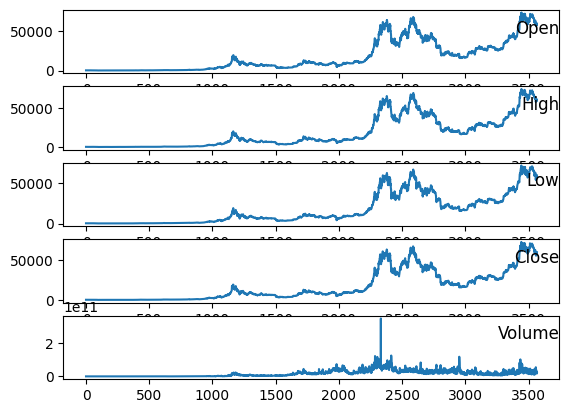

In [ ]:


values = doc1.values
groups = [0, 1, 2, 3, 4]
i = 1
# plot each column
for group in groups:
    plt.subplot(len(groups), 1, i)
    plt.plot(values[:, group])
    plt.title(doc1.columns[group], y=0.5, loc='right')
    i += 1


plt.show()

2. Bitcoin Closing Price over time# Plot the data

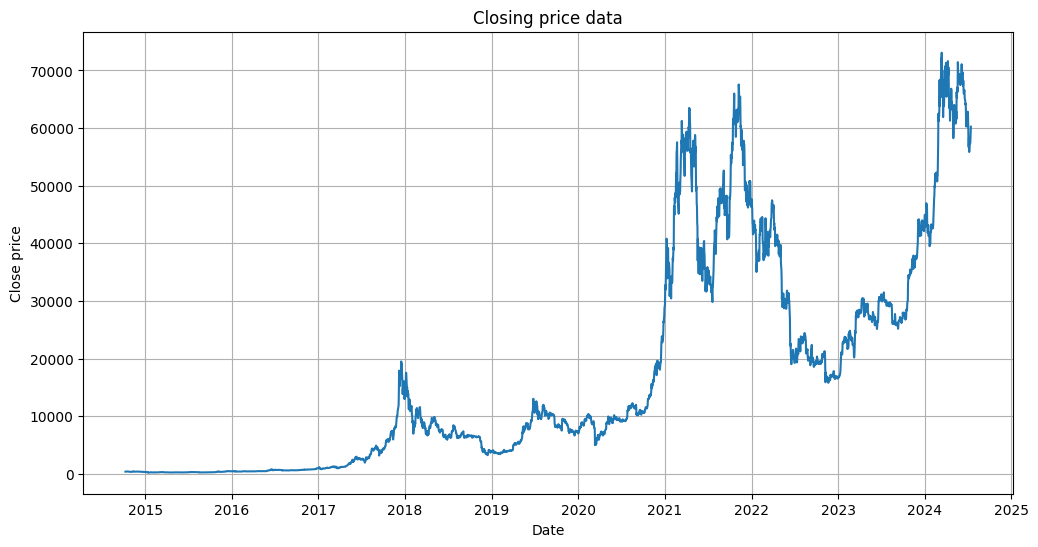

In [ ]:

plt.figure(figsize=(12, 6))
plt.plot(doc1['Close'])
plt.title('Closing price data')
plt.xlabel('Date')
plt.ylabel('Close price')
plt.grid(True)
plt.show()


3. Bitcoin monthly average close price over time

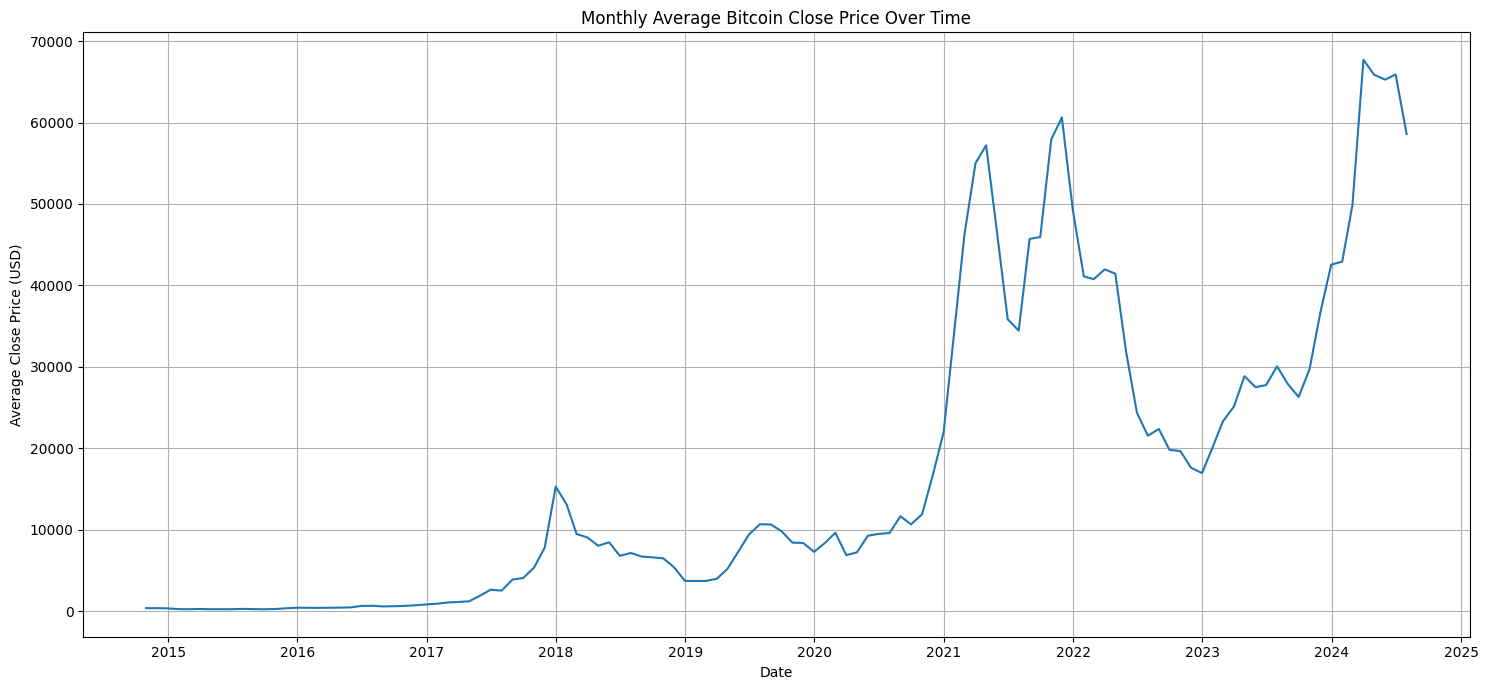

In [ ]:

# Reconstruct Datetime Index and set it as index
doc2=doc1.copy()
doc2['Date'] = pd.to_datetime(doc2['Date'], format='%d-%m-%Y') # Convert 'Date' to datetime objects
doc2['YEAR'] = doc2['Date'].dt.year
doc2['MONTH'] = doc2['Date'].dt.month
doc2['DAY'] = doc2['Date'].dt.day
doc2['Datetime'] = pd.to_datetime(doc2[['YEAR', 'MONTH', 'DAY']])
doc2.set_index('Datetime', inplace=True)
doc2.drop(columns=['YEAR', 'MONTH', 'DAY', 'Date'], inplace=True)

# Resample to monthly frequency (Month End) and calculate the mean
doc_monthly = doc2.resample('ME').mean() # Changed doc to doc2

# Create the line plot for monthly average close price
plt.figure(figsize=(15, 7))
sns.lineplot(x=doc_monthly.index, y=doc_monthly['Close'])
plt.title('Monthly Average Bitcoin Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Close Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

6. **Time Series forecast with Trend + Seasonality**

In [ ]:
doc_monthly_ = doc1.resample('ME').mean()
display(doc_monthly_.head())
doc_monthly_.shape

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-10-31,371.043045,378.246001,362.539637,369.854911,369.854911,1.940693e+07
2014-11-30,364.850235,376.494235,357.241832,366.099799,366.099799,2.199111e+07
2014-12-31,343.074836,347.487129,336.565775,341.267871,341.267871,1.784201e+07
2015-01-31,251.799905,261.391583,240.495550,248.782547,248.782547,3.544555e+07
2015-02-28,232.821856,240.211430,227.769678,234.153645,234.153645,2.541138e+07


(118, 6)

In [ ]:
# Define Y as the 'Close' prices
Y = doc_monthly_['Close']

# Define time as a numerical index for the months
time = np.arange(len(Y))

print(f"Length of Y: {len(Y)}")
print(f"Length of time: {len(time)}")

Length of Y: 118
Length of time: 118


In [ ]:


# Perform seasonal decomposition to extract the seasonal component
# Assuming yearly seasonality (period=12 for monthly data)
decomposition = seasonal_decompose(Y, model='additive', period=12)
seasonal = decomposition.seasonal

# Display the first few seasonal values
print("First few seasonal values:")
print(seasonal.head())

First few seasonal values:
Date
2014-10-31    -946.951899
2014-11-30     -23.099011
2014-12-31    -165.844958
2015-01-31      66.666448
2015-02-28    1763.244039
Freq: ME, Name: seasonal, dtype: float64


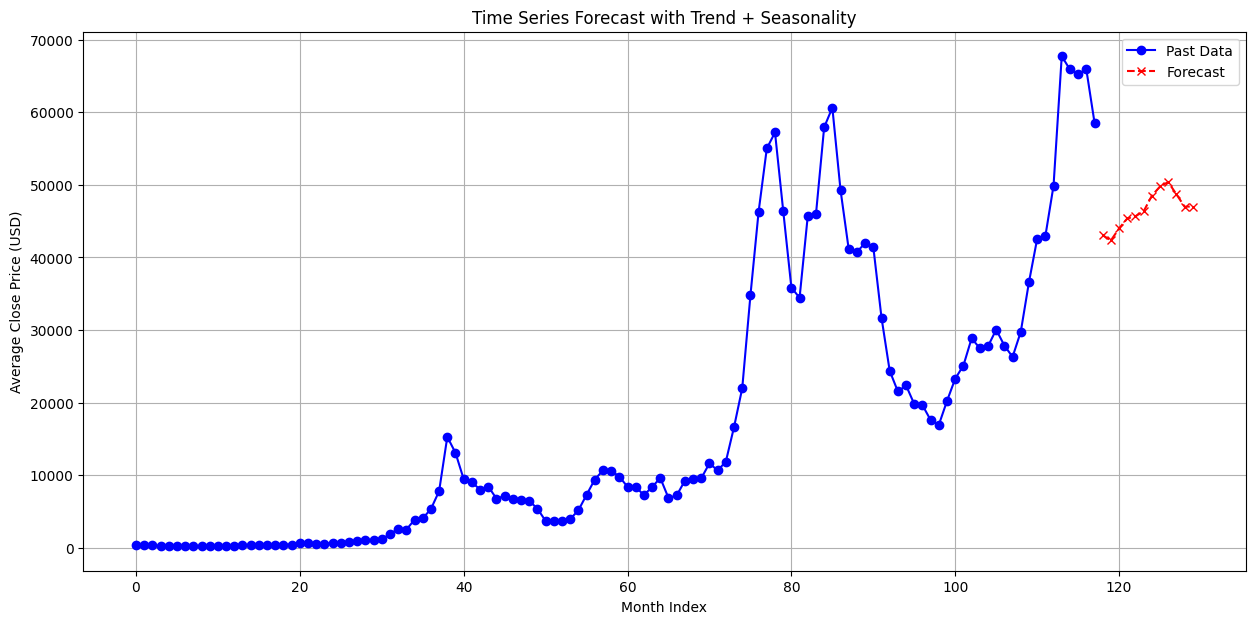

In [ ]:


# Forecast horizon
future_months = np.arange(len(Y), len(Y) + 12)  # next 12 months after the last data point

# Trend forecasting
X = time.reshape(-1,1)
y = Y
model = LinearRegression()
model.fit(X, y)
trend_forecast = model.predict(future_months.reshape(-1,1))

# Repeat seasonal pattern (last 12 months pattern)
seasonal_pattern = seasonal[-12:]  # last year's seasonal pattern

# Ensure seasonal_forecast has the correct length to match future_months
# This handles cases where len(future_months) is not a multiple of 12
seasonal_forecast = np.tile(seasonal_pattern, (len(future_months) + 11) // 12)[:len(future_months)]

# Combined forecast
forecast = trend_forecast + seasonal_forecast

# Plot past + forecast
plt.figure(figsize=(15,7))
plt.plot(time, Y, marker='o', color='blue', label="Past Data")
plt.plot(future_months, forecast, marker='x', linestyle='--', color='red', label="Forecast")
plt.title("Time Series Forecast with Trend + Seasonality")
plt.xlabel("Month Index")
plt.ylabel("Average Close Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

7. **Decomposing time series**

One of the most common analysis for time series is decomposing it into multiple parts. The parts we can divide a time series into are: level, trend, seasonality and noise, all series contain level and noise but seasonality and trend are not always present (there will be more analysis for this two parts).

This 4 parts can combine either additively or multiplicatively into the time series.

Automatic time series decomposition
Statsmodel python library provides a function seasonal_compose() to automatically decompose a time series, you still need to specify wether the model is additive or multiplicative. We will use multiplicative as our quick peak at the pm2.5 time series shows no linear trend

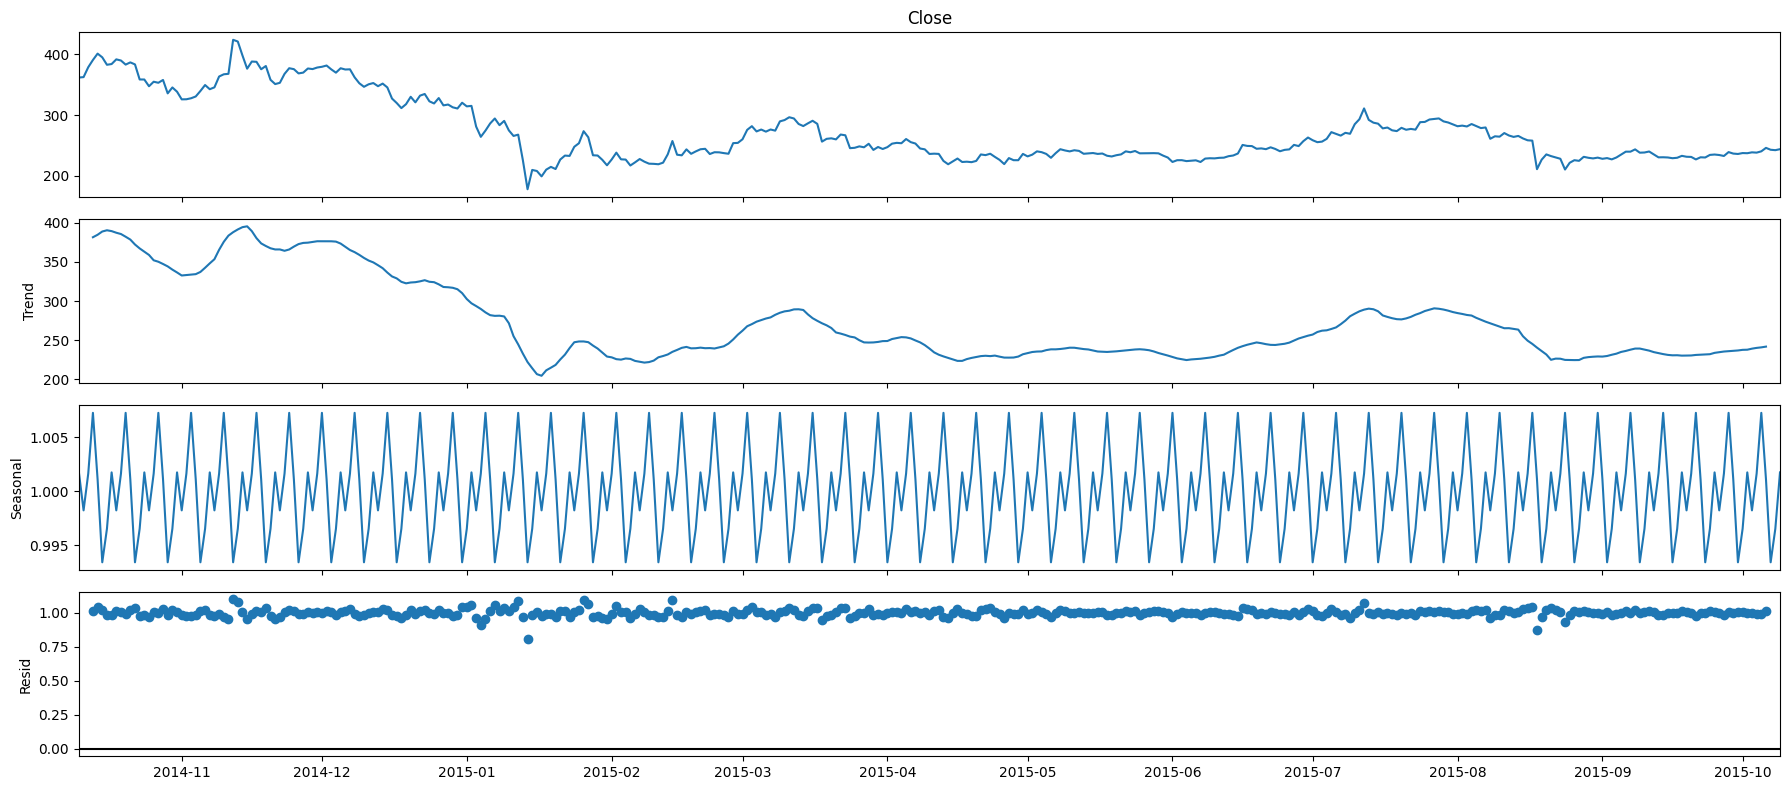

<Figure size 4000x1600 with 0 Axes>

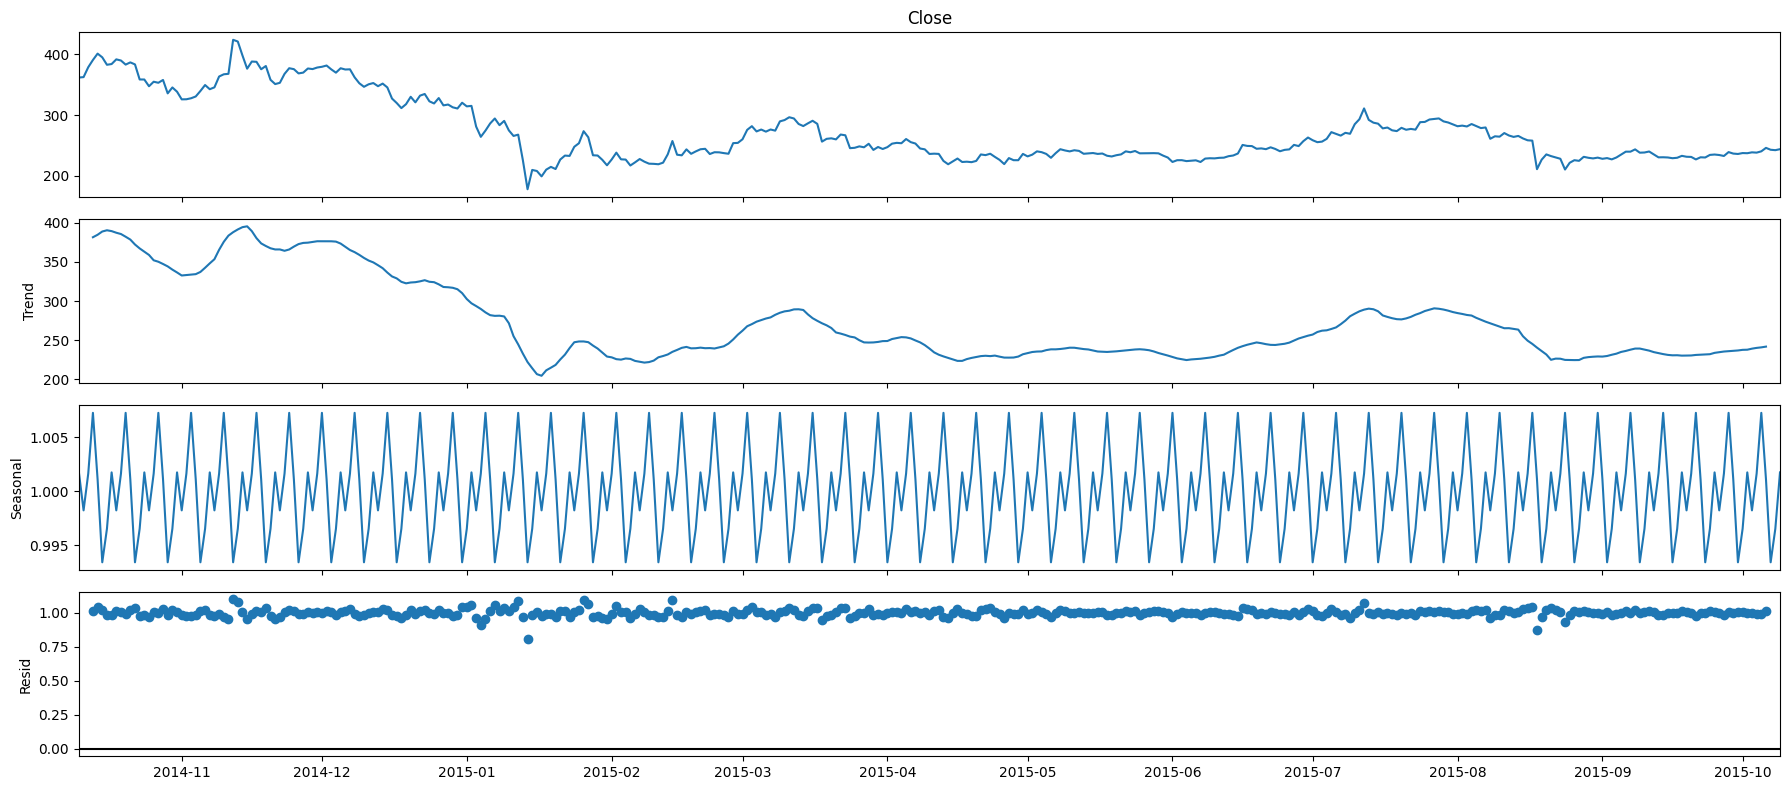

In [ ]:
rcParams['figure.figsize'] = 18, 8
plt.figure(num=None, figsize=(50, 20), dpi=80, facecolor='w', edgecolor='k')
series = doc1.Close[:365]
result = seasonal_decompose(series, model='multiplicative')
result.plot()

1. Trend

A trend is observed when there is an increasing or decreasing slope observed in the time series. A trend is a smooth, general, long-term, average tendency. It is not always necessary that the increase or decrease is in the same direction throughout the given period of time.

Trend can be removed from your time series data (and data in the future) as a data preparation and cleaning exercise. This is common when using statistical methods for time series forecasting, but does not always improve results when using machine learning models. We will see different methods for this in the making your series stationary section

In practice, identifying a trend in a time series can be a subjective process as we are never sure if contains seasonalities or noise to it, Create line plots of your data and inspect the plots for obvious trends.

Now we will try some methods to check for trend in our series:

1) Automatic decomposing
2) Moving average
3) Fit a linear regression model to identify trend

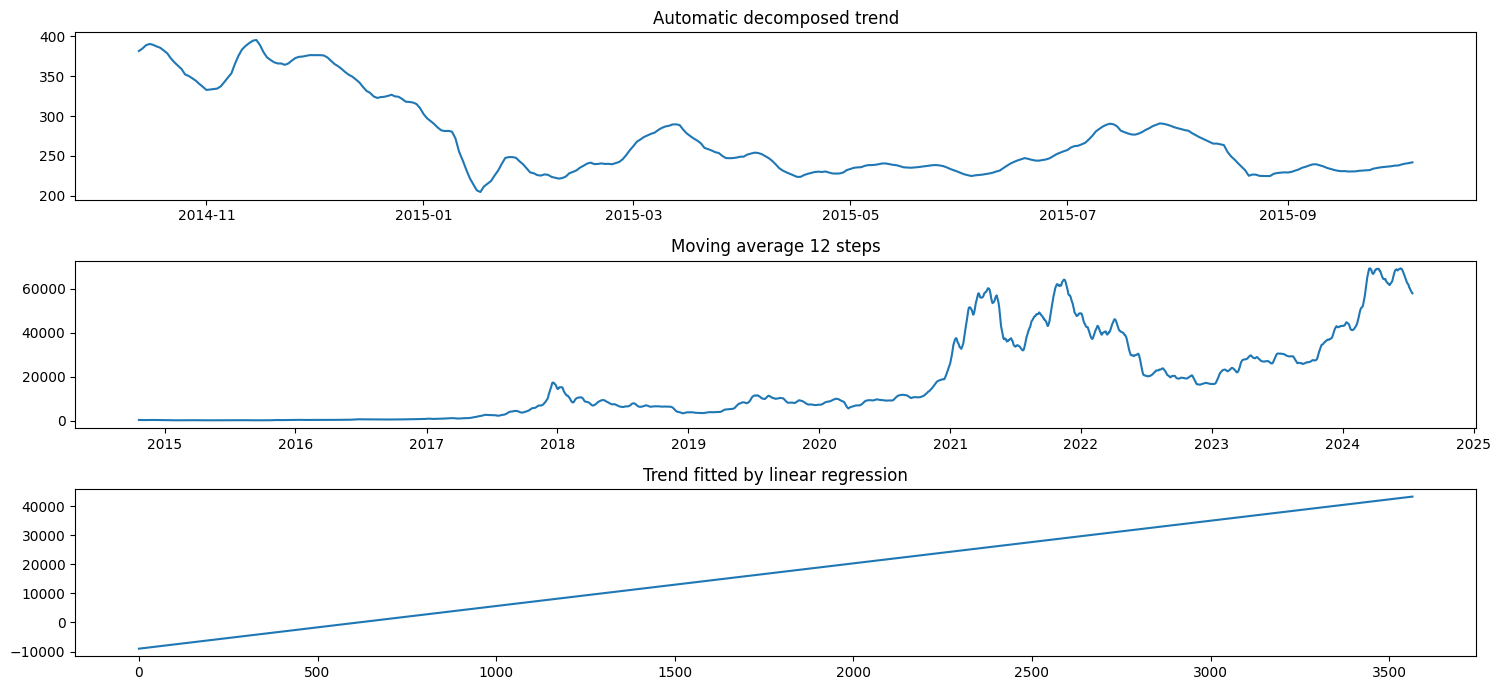

In [ ]:
fig = plt.figure(figsize=(15, 7))
layout = (3, 2)
pm_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
mv_ax = plt.subplot2grid(layout, (1, 0), colspan=2)
fit_ax = plt.subplot2grid(layout, (2, 0), colspan=2)

pm_ax.plot(result.trend)
pm_ax.set_title("Automatic decomposed trend")

mm = doc1.Close.rolling(12).mean()
mv_ax.plot(mm)
mv_ax.set_title("Moving average 12 steps")


X = [i for i in range(0, len(doc1.Close))]
X = np.reshape(X, (len(X), 1))
y = doc1.Close.values
model = LinearRegression()
model.fit(X, y)
# calculate trend
trend = model.predict(X)
fit_ax.plot(trend)
fit_ax.set_title("Trend fitted by linear regression")

plt.tight_layout()

We can see our series does have a strong trend

2. Manual methods to find seasonalities

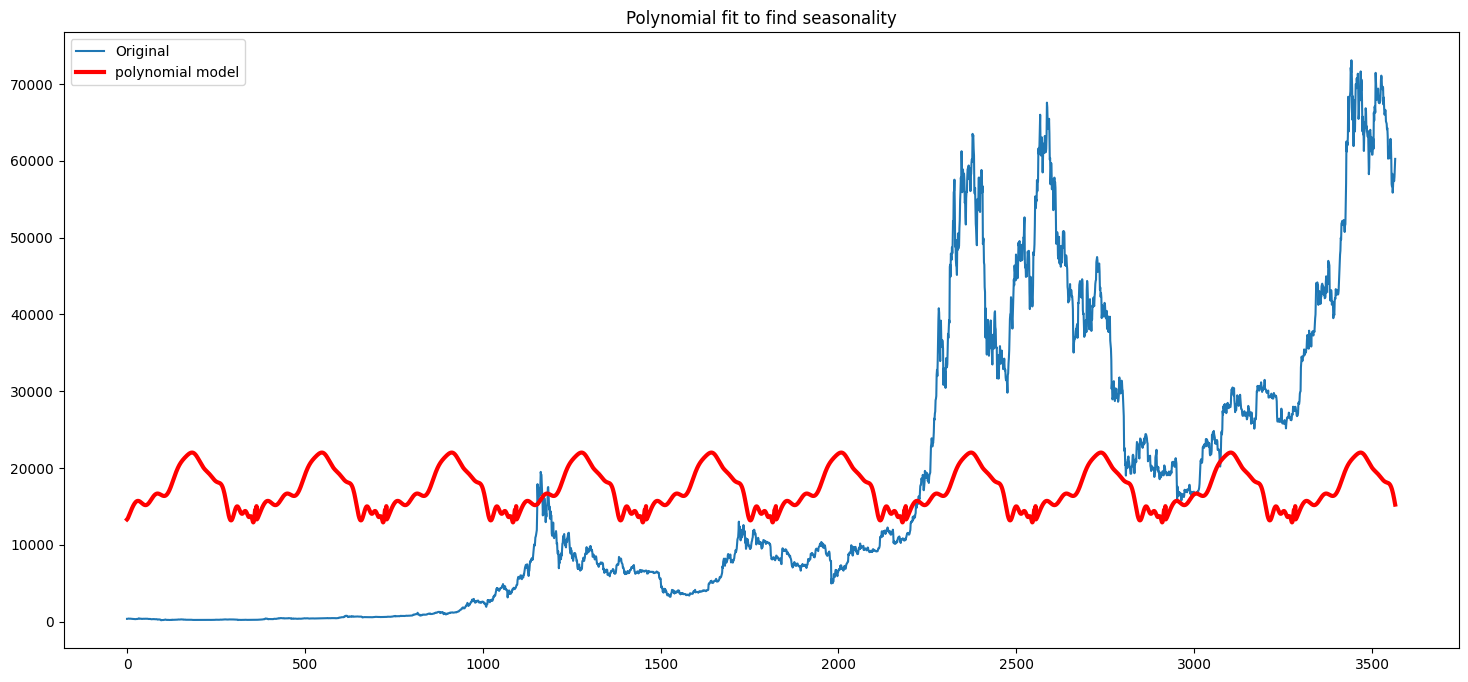

In [ ]:
# Fix xticks to show dates
# fit polynomial: x^2*b1 + x*b2 + ... + bn
series = doc1.Close.values
X = [i % 365 for i in range(0, len(series))]
y = series
degree = 100
coef = np.polyfit(X, y, degree)
# create curve
curve = list()
for i in range(len(X)):
    value = coef[-1]
    for d in range(degree):
        value += X[i]**(degree-d) * coef[d]
    curve.append(value)
# plot curve over original data
plt.plot(series, label='Original')
plt.plot(curve, color='red', linewidth=3, label='polynomial model')
plt.legend()
plt.title("Polynomial fit to find seasonality")
plt.show()

3. F**inding p and q using PACF and ACF**

 Number significant terms in ACF is the value q, order of MA

Number significant terms in PACF is the value p, order of AR

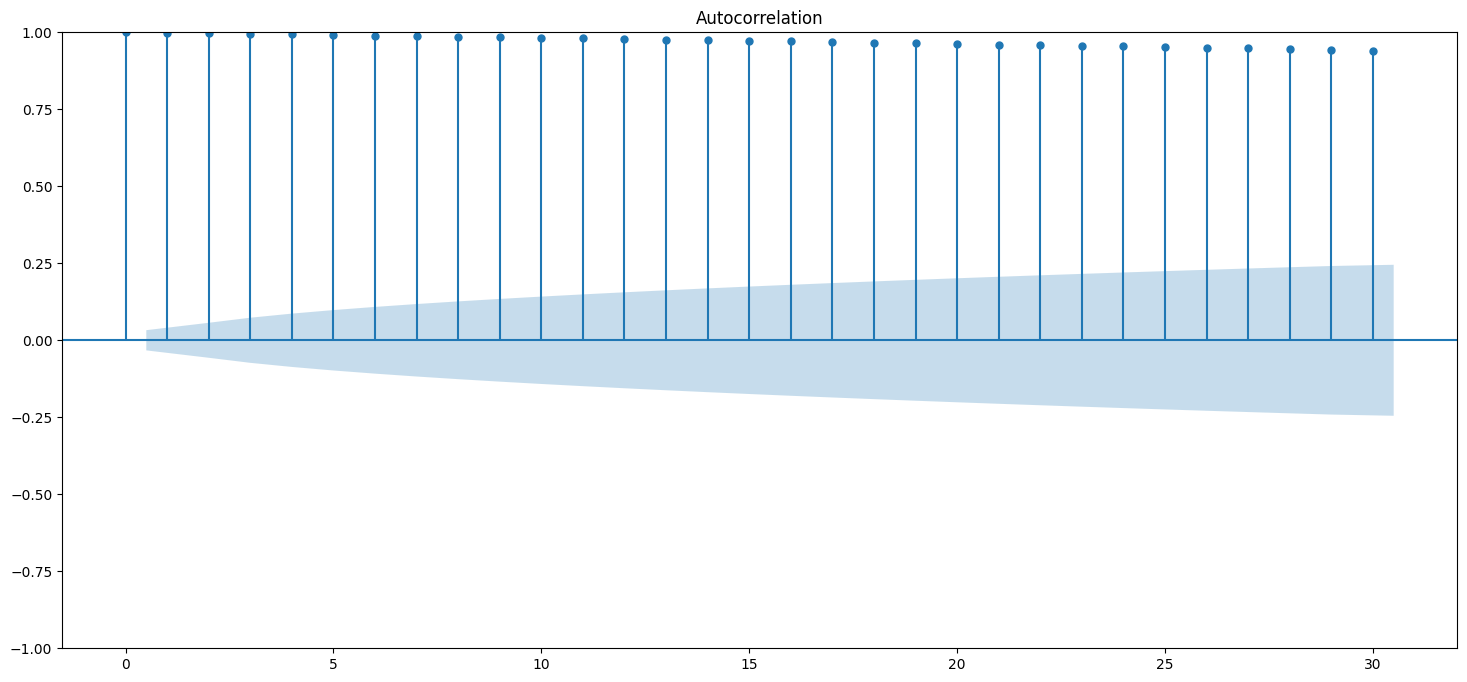

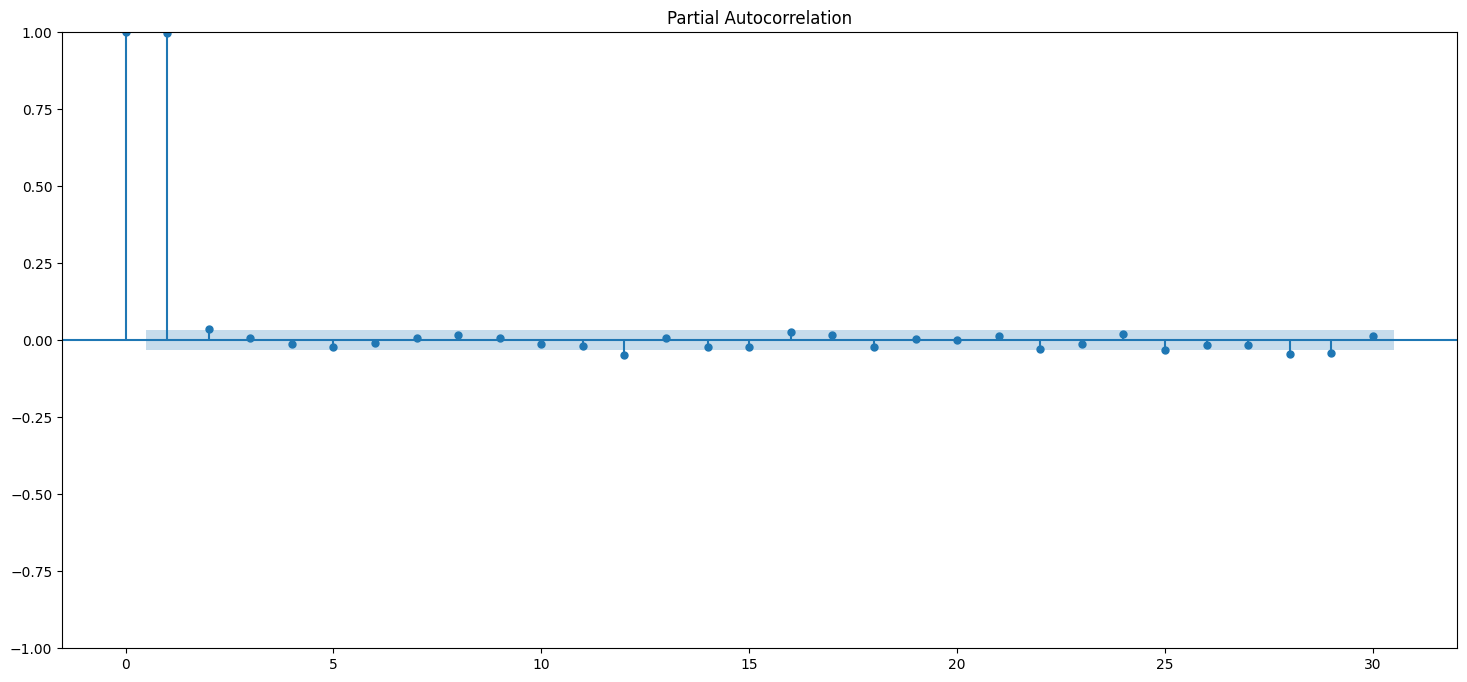

In [ ]:
plot_acf(series, lags=30)
plot_pacf(series, lags=30)
plt.show()

**4. Stationarity**


Stationarity is an important characteristic of time series. A time series is stationarity if it has constant mean and variance over time. Most models work only with stationary data as this makes it easier to model. Not all time series are stationary but we can transform them into stationary series in different ways.

In [ ]:
X = doc1.Close.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -1.093811
p-value: 0.717533
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567


Augmented Dickey-Fuller test
The Augmented Dickey-Fuller test is a type of statistical test called a unit root test. The intuition behind a unit root test is that it determines how strongly a time series is defined by a trend. There are a number of unit root tests and the Augmented Dickey-Fuller may be one of the more widely used. It uses an autoregressive model and optimizes an information criterion across multiple different lag values.

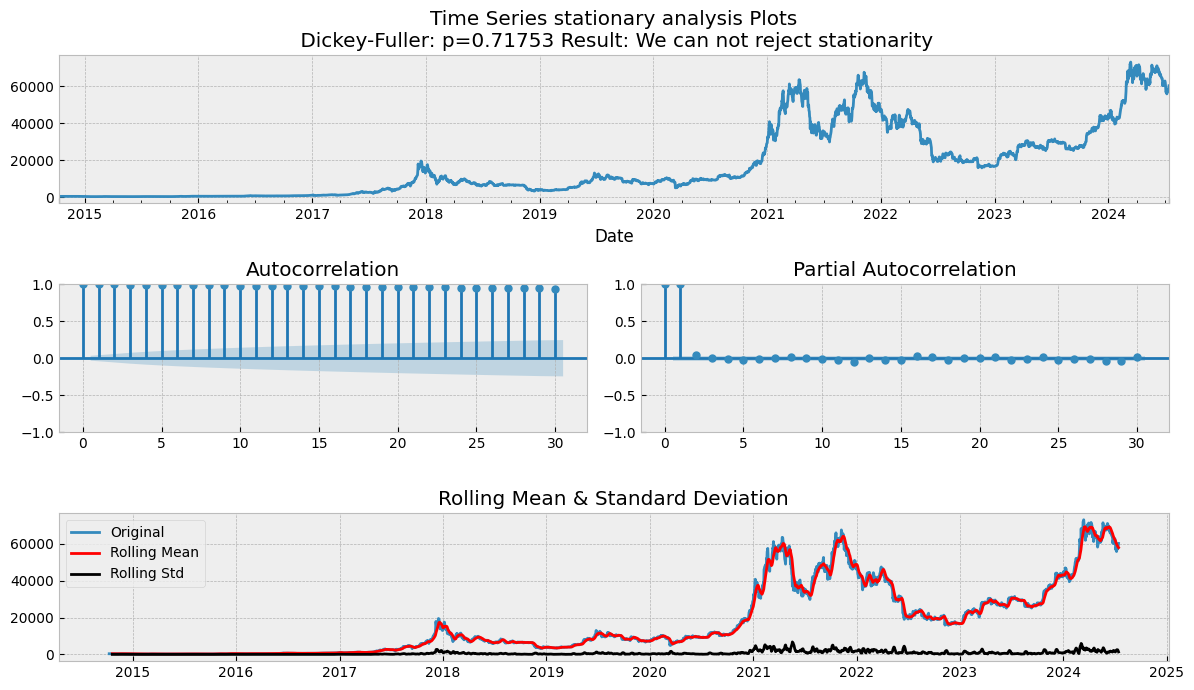

In [ ]:
def tsplot(y, lags=None, figsize=(12, 7), syle='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style='bmh'):
        fig = plt.figure(figsize=(12, 7))
        layout = (3, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        mean_std_ax = plt.subplot2grid(layout, (2, 0), colspan=2)
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        hypothesis_result = "We reject stationarity" if p_value <= 0.05 else "We can not reject stationarity"
        ts_ax.set_title(
            'Time Series stationary analysis Plots\n Dickey-Fuller: p={0:.5f} Result: {1}'.format(p_value, hypothesis_result))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

        rolmean = doc1.Close.rolling(window=12).mean()
        rolstd = doc1.Close.rolling(window=12).std()

        # Plot rolling statistics:
        orig = plt.plot(doc1.Close, label='Original')
        mean = plt.plot(rolmean, color='red', label='Rolling Mean')
        std = plt.plot(rolstd, color='black', label='Rolling Std')
        plt.legend(loc='best')
        plt.title('Rolling Mean & Standard Deviation')


tsplot(doc1.Close, lags=30)

In [ ]:
def difference(dataset, interval=1, order=1):
    for u in range(order):
        diff = list()
        for i in range(interval, len(dataset)):
            value = dataset[i] - dataset[i - interval]
            diff.append(value)
        dataset = diff
    return diff

5. **Making Time Series Stationary**

Difference transform
Applying a difference transform to a time series could help remove the series dependence on time.

This transform is done by substracting the previous obesvation to the current one.

difference(t) = observation(t) - observation(t-1)

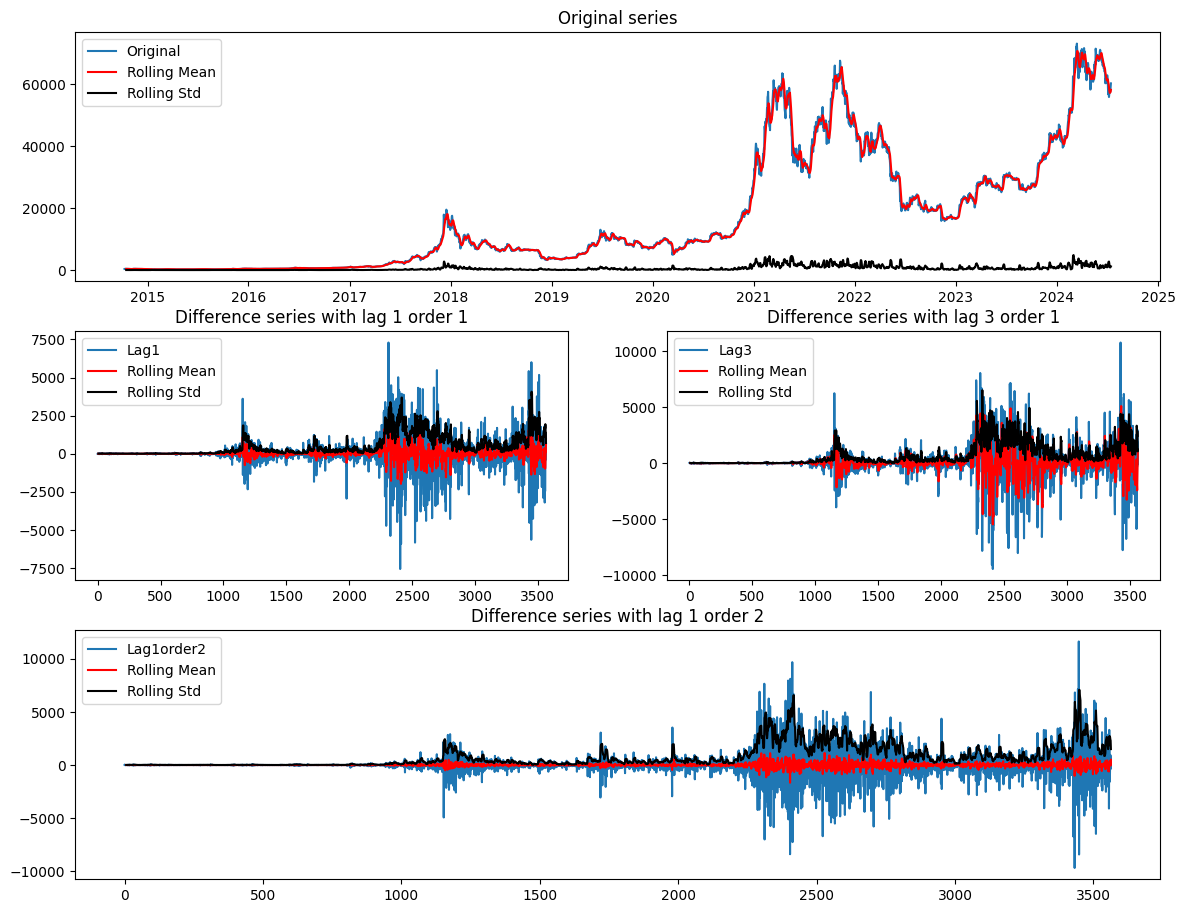

In [ ]:
lag1series = pd.Series(difference(doc1.Close, interval=1, order=1))
lag3series = pd.Series(difference(doc1.Close, interval=3, order=1))
lag1order2series = pd.Series(difference(
    doc1.Close, interval=1, order=2))

fig = plt.figure(figsize=(14, 11))
layout = (3, 2)
original = plt.subplot2grid(layout, (0, 0), colspan=2)
lag1 = plt.subplot2grid(layout, (1, 0))
lag3 = plt.subplot2grid(layout, (1, 1))
lag1order2 = plt.subplot2grid(layout, (2, 0), colspan=2)

original.set_title('Original series')
original.plot(doc1.Close, label='Original')
original.plot(doc1.Close.rolling(
    7).mean(), color='red', label='Rolling Mean')
original.plot(doc1.Close.rolling(7).std(),
              color='black', label='Rolling Std')
original.legend(loc='best')

lag1.set_title('Difference series with lag 1 order 1')
lag1.plot(lag1series, label="Lag1")
lag1.plot(lag1series.rolling(7).mean(), color='red', label='Rolling Mean')
lag1.plot(lag1series.rolling(7).std(), color='black', label='Rolling Std')
lag1.legend(loc='best')

lag3.set_title('Difference series with lag 3 order 1')
lag3.plot(lag3series, label="Lag3")
lag3.plot(lag3series.rolling(7).mean(), color='red', label='Rolling Mean')
lag3.plot(lag3series.rolling(7).std(), color='black', label='Rolling Std')
lag3.legend(loc='best')

lag1order2.set_title('Difference series with lag 1 order 2')
lag1order2.plot(lag1order2series, label="Lag1order2")
lag1order2.plot(lag1order2series.rolling(7).mean(),
                color='red', label='Rolling Mean')
lag1order2.plot(lag1order2series.rolling(7).std(),
                color='black', label='Rolling Std')
lag1order2.legend(loc='best')

Log scale transformation

Text(0.5, 1.0, 'Log scale transformation into original series')

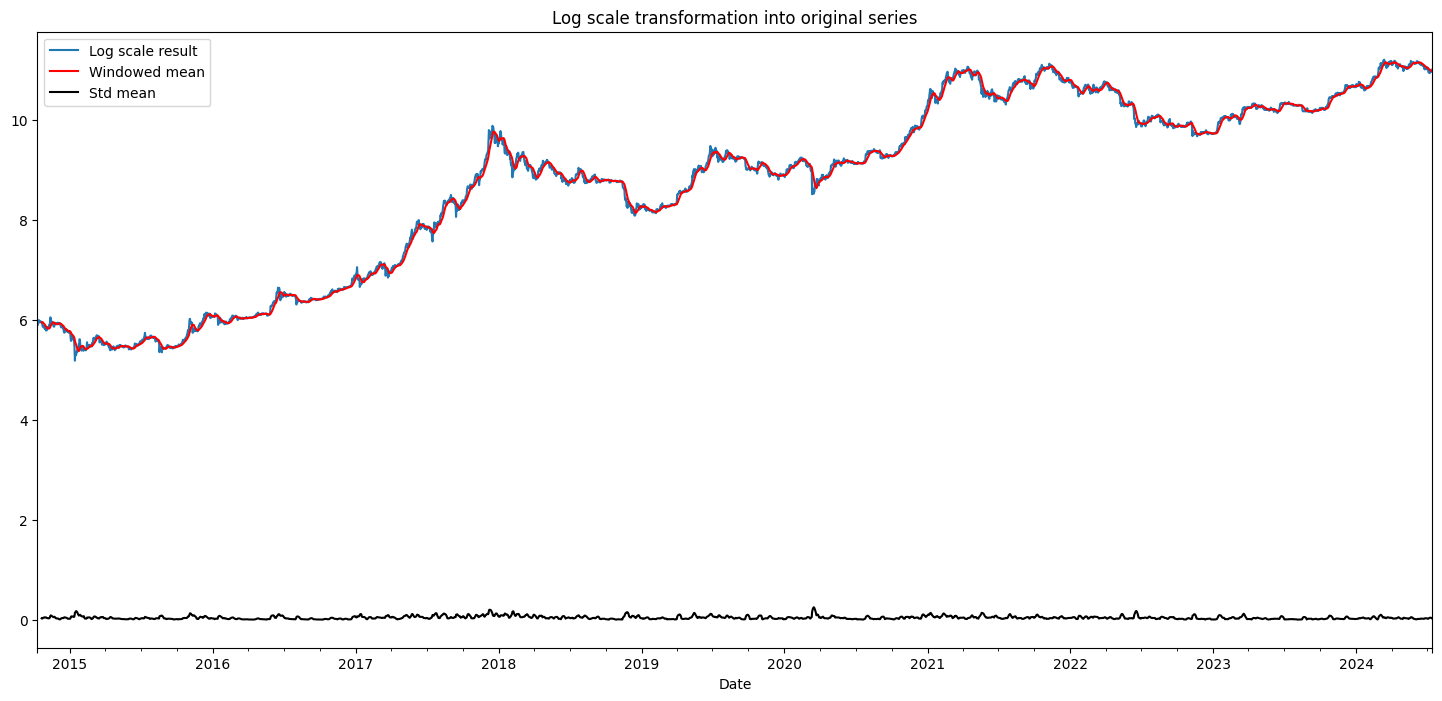

In [ ]:
ts_log = np.log(doc1.Close)
ts_log.plot(label='Log scale result')
ts_log.rolling(window=12).mean().plot(color='red', label='Windowed mean')
ts_log.rolling(window=12).std().plot(color='black', label='Std mean')
plt.legend()
plt.title('Log scale transformation into original series')

Smoothing

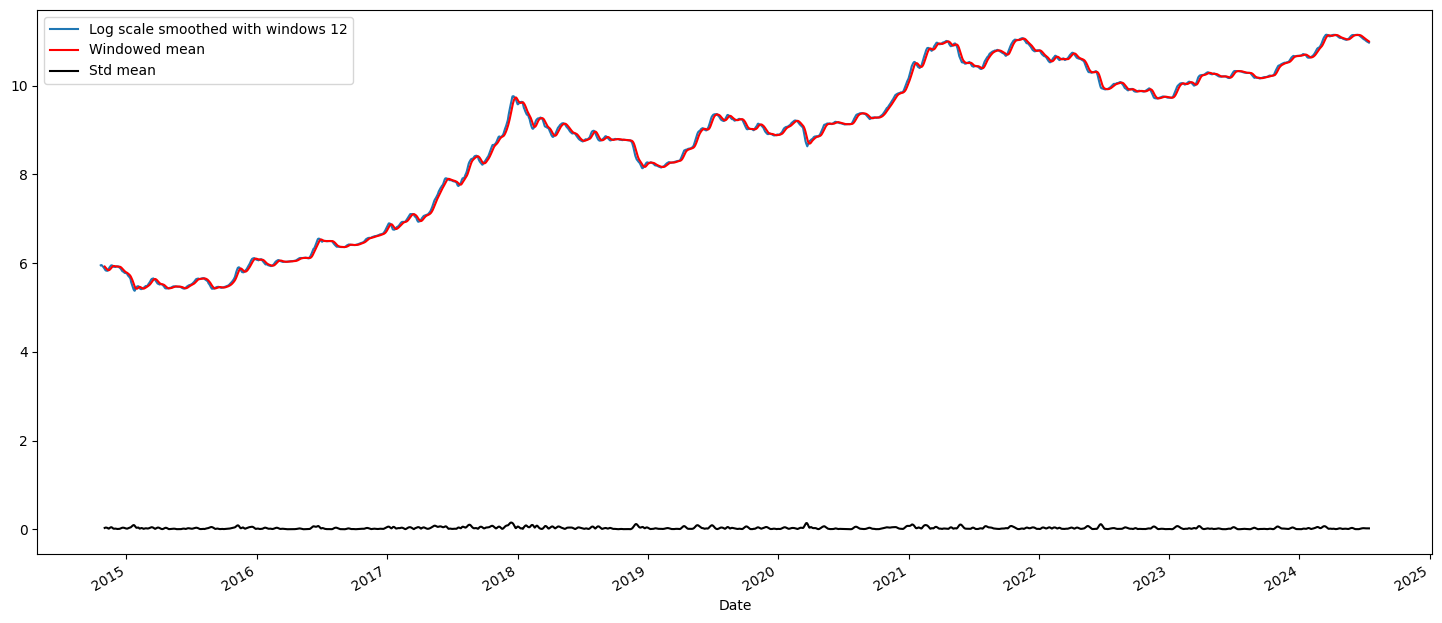

In [ ]:
avg = pd.Series(ts_log).rolling(12).mean()
plt.plot(avg, label='Log scale smoothed with windows 12')
avg.rolling(window=12).mean().plot(color='red', label='Windowed mean')
avg.rolling(window=12).std().plot(color='black', label='Std mean')
plt.legend()

We can combine it with our previous log scale and apply differencing

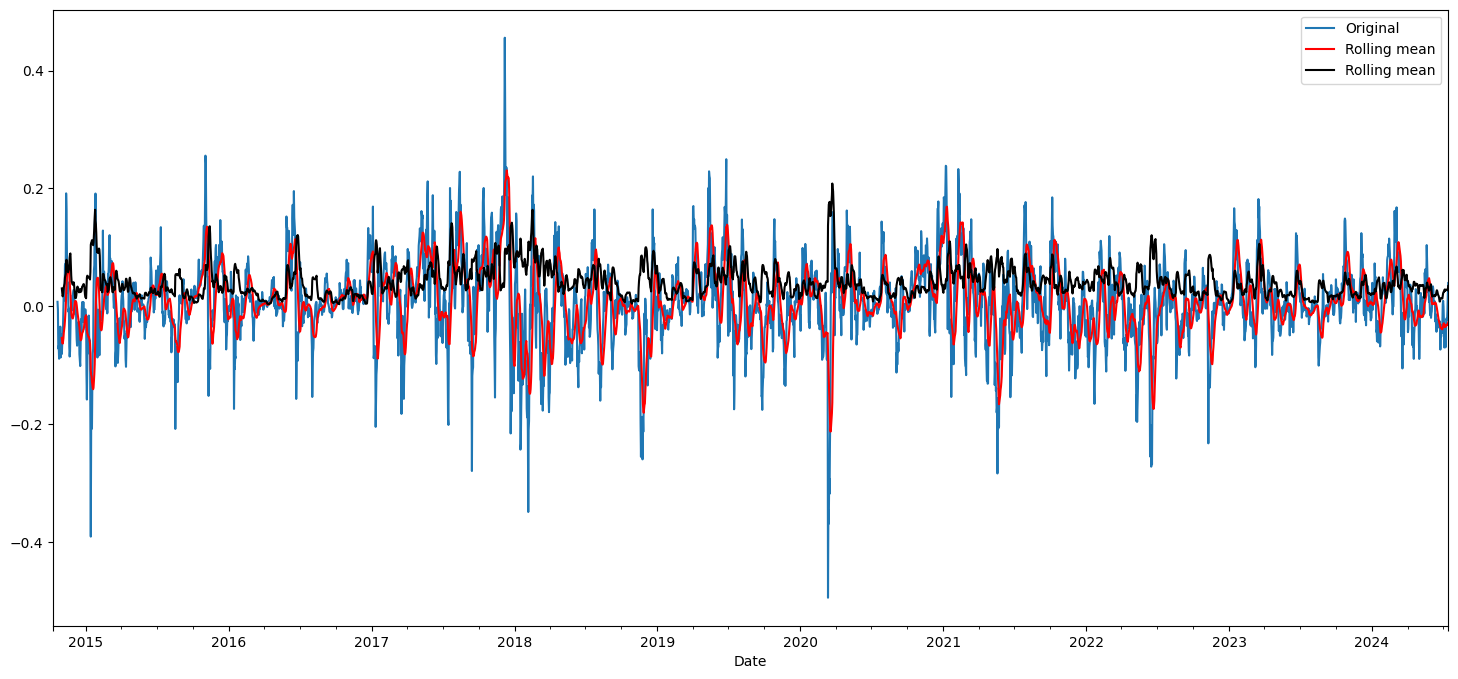

In [ ]:
ts_log_moving_avg_diff = ts_log - avg

ts_log_moving_avg_diff.plot(label='Original')
ts_log_moving_avg_diff.rolling(12).mean().plot(
    color='red', label="Rolling mean")
ts_log_moving_avg_diff.rolling(12).std().plot(
    color='black', label="Rolling mean")
plt.legend(loc='best')

**8.  Methods for time series forecasting**


There are many methods that we can use for time series forecasting and there is not a clear winner. Model selection should always depend on how you data look and what are you trying to achieve. Some models may be more robust against outliers but perform worse than the more sensible and could still be the best choice depending on the use case.

When looking at your data the main split is wether we have extra regressors (features) to our time series or just the series. Based on this we can start exploring different methods for forecasting and their performance in different metrics.

In this section we will show models for both cases, time series with and without extra regressors.

Prepare data before modeling

In [11]:
# We split our dataset to be able to evaluate our models

resultsDict = {}
predictionsDict = {}

split_date = '2023-01-01'
df_training = doc1.loc[doc1.index <= split_date]
df_test = doc1.loc[doc1.index > split_date]
print(f"{len(df_training)} days of training data \n {len(df_test)} days of testing data ")

3006 days of training data 
 560 days of testing data 


1. Simple Exponential Smoothing (SES)


The Simple Exponential Smoothing (SES) method models the next time step as an exponentially weighted linear function of observations at prior time steps. This method expects our time series to be non stationary in order to perform adecuately (no trend or seasonality)

In [ ]:
# Walk through the test data, training and predicting 1 day ahead for all the test data
index = len(df_training)
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    model = SimpleExpSmoothing(temp_train.Close)
    model_fit = model.fit()
    predictions = model_fit.predict(start=len(temp_train), end=len(temp_train))
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['SES'] = evaluate(df_test.Close, yhat.values)
predictionsDict['SES'] = yhat.values

100%|██████████| 560/560 [00:09<00:00, 61.89it/s]


2. Holt Winter’s Exponential Smoothing (HWES)

HWES or also known as triple exponential smoothing

In [ ]:
# Walk throught the test data, training and predicting 1 day ahead for all the test data
index = len(df_training)
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    model = ExponentialSmoothing(temp_train.Close)
    model_fit = model.fit()
    predictions = model_fit.predict(start=len(temp_train), end=len(temp_train))
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['HWES'] = evaluate(df_test.Close, yhat.values)
predictionsDict['HWES'] = yhat.values

100%|██████████| 560/560 [00:11<00:00, 47.37it/s]


3. Autoregression (AR)

The autoregression (AR) method models the next step in the sequence as a linear function of the observations at prior time steps. Parameters of the model:

Number of AR (Auto-Regressive) terms (p): p is the parameter associated with the auto-regressive aspect of the model, which incorporates past values i.e lags of dependent variable. For instance if p is 5, the predictors for x(t) will be x(t-1)….x(t-5).

In [ ]:
# Walk throught the test data, training and predicting 1 day ahead for all the test data
index = len(df_training)
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    # Fix: 'lags' must be an integer, not 'auto'
    model = AutoReg(temp_train.Close, lags=2)
    model_fit = model.fit()
    predictions = model_fit.predict( start=len(temp_train), end=len(temp_train),dynamic=False)


    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['AutoReg'] = evaluate(df_test.Close, yhat.values)
predictionsDict['AutoReg'] = yhat.values

100%|██████████| 560/560 [00:02<00:00, 188.58it/s]


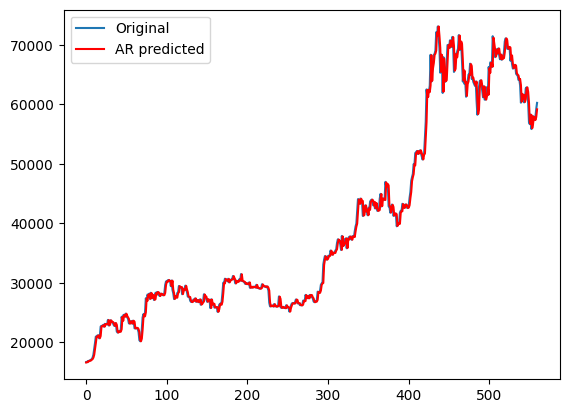

In [ ]:
plt.plot(df_test.Close.values, label='Original')
plt.plot(yhat.values, color='red', label='AR predicted')
plt.legend()

4. Moving Average (MA)

The Moving Average (MA) method models the next step in the sequence as the average of a window of observations at prior time steps.

In [ ]:
# MA example

# Walk throught the test data, training and predicting 1 day ahead for all the test data
index = len(df_training)
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    # Fix: Replace deprecated ARMA with ARIMA (0,0,1)
    model = ARIMA(temp_train.Close, order=(0, 0, 1))
    model_fit = model.fit()
    predictions = model_fit.predict(
        start=len(temp_train), end=len(temp_train), dynamic=False)
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['MA'] = evaluate(df_test.Close, yhat.values)
predictionsDict['MA'] = yhat.values

In [ ]:
plt.plot(df_test.Close.values, label='Original')
plt.plot(yhat.values, color='red', label='MA predicted')
plt.legend()

5. Autoregressive Moving Average (ARMA)


This method will basically join the previous two AR and MA. Model parameters will be the sum of the two.

In [ ]:
# ARMA example

# Walk throught the test data, training and predicting 1 day ahead for all the test data
index = len(df_training)
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    # Fix: Replace deprecated ARMA with ARIMA (p, d, q). ARMA(1,1) is equivalent to ARIMA(1,0,1).
    # Also, remove disp=False as it's not supported by the new ARIMA model.
    model = ARIMA(temp_train.Close, order=(1, 0, 1))
    model_fit = model.fit()
    predictions = model_fit.predict(
        start=len(temp_train), end=len(temp_train), dynamic=False)
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['ARMA'] = evaluate(df_test.Close, yhat.values)
predictionsDict['ARMA'] = yhat.values

100%|██████████| 560/560 [05:51<00:00,  1.60it/s]


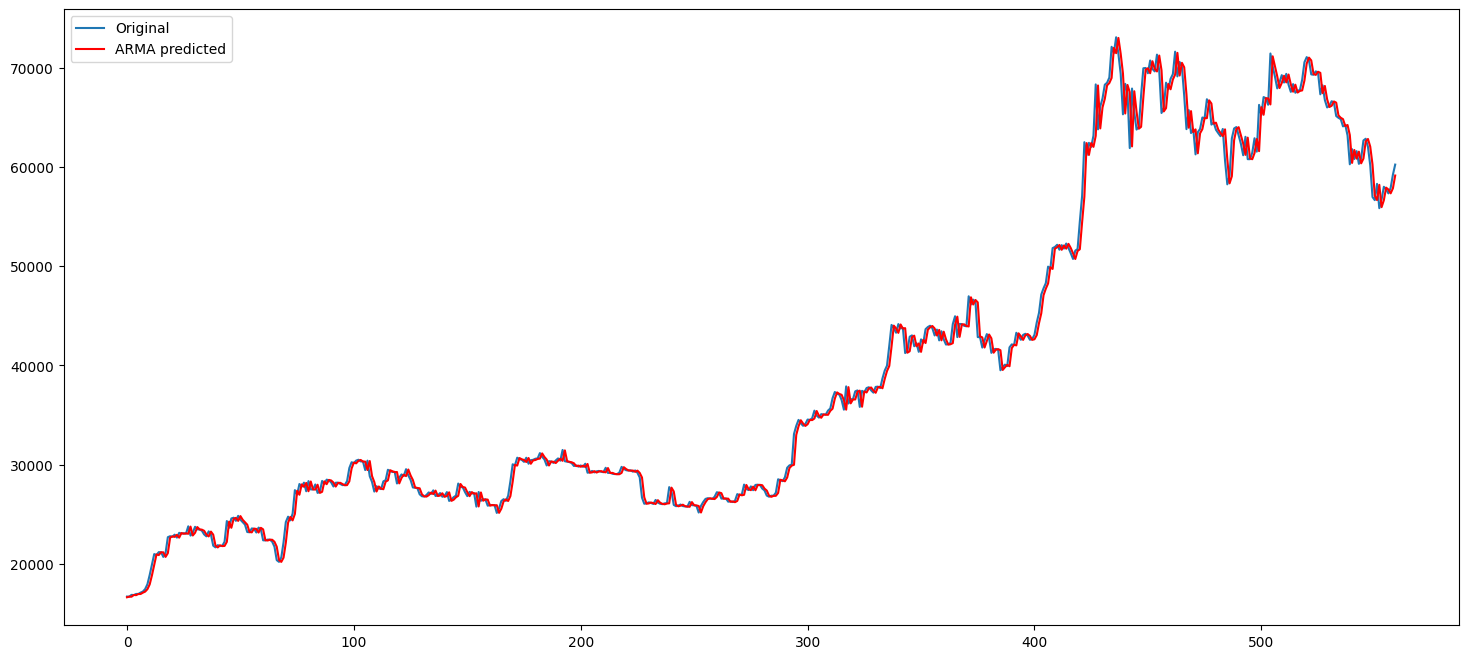

In [ ]:
plt.plot(df_test.Close.values, label='Original')
plt.plot(yhat.values, color='red', label='ARMA predicted')
plt.legend()

6. Autoregressive integrated moving average (ARIMA)

In an ARIMA model there are 3 parameters that are used to help model the major aspects of a times series: seasonality, trend, and noise. These parameters are labeled p,d,and q.

In [ ]:
# ARIMA example

# Walk throught the test data, training and predicting 1 day ahead for all the test data
index = len(df_training)
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    model = ARIMA(temp_train.Close, order=(1, 0, 0))
    model_fit = model.fit()
    predictions = model_fit.predict(
        start=len(temp_train), end=len(temp_train), dynamic=False)
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['ARIMA'] = evaluate(df_test.Close, yhat.values)
predictionsDict['ARIMA'] = yhat.values

100%|██████████| 560/560 [01:45<00:00,  5.32it/s]


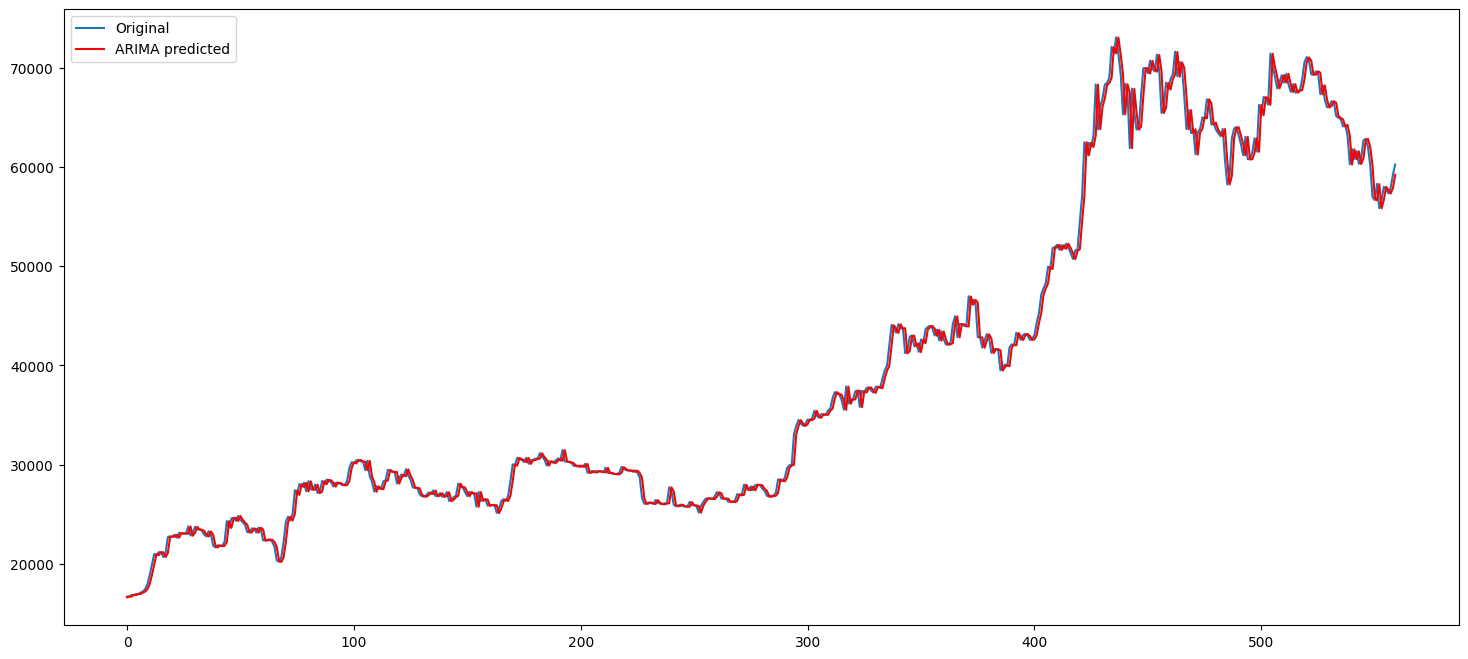

In [ ]:
plt.plot(df_test.Close.values, label='Original')
plt.plot(yhat.values, color='red', label='ARIMA predicted')
plt.legend()

7. Auto ARIMA

In [ ]:
# building the model

autoModel = pm.auto_arima(df_training.Close, trace=True,
                          error_action='ignore', suppress_warnings=True, seasonal=False)
autoModel.fit(df_training.Close)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=48671.500, Time=6.93 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=48690.742, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=48690.774, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=48690.794, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=48688.880, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=48693.150, Time=1.20 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=48694.729, Time=0.59 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=48673.477, Time=8.43 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=48673.543, Time=4.40 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=48692.761, Time=0.31 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=48693.431, Time=1.96 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=48693.644, Time=1.73 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=48675.187, Time=10.04 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=48669.684, Time=3.38 sec
 ARIMA(1,1,2)(0,0,

ARIMA(order=(2, 1, 2), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [ ]:
order = autoModel.order
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    model = ARIMA(temp_train.Close, order=order)
    model_fit = model.fit()
    predictions = model_fit.predict(
        start=len(temp_train), end=len(temp_train), dynamic=False)
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['AutoARIMA {0}'.format(order)] = evaluate(
    df_test.Close, yhat)
predictionsDict['AutoARIMA {0}'.format(order)] = yhat.values

100%|██████████| 560/560 [14:26<00:00,  1.55s/it]


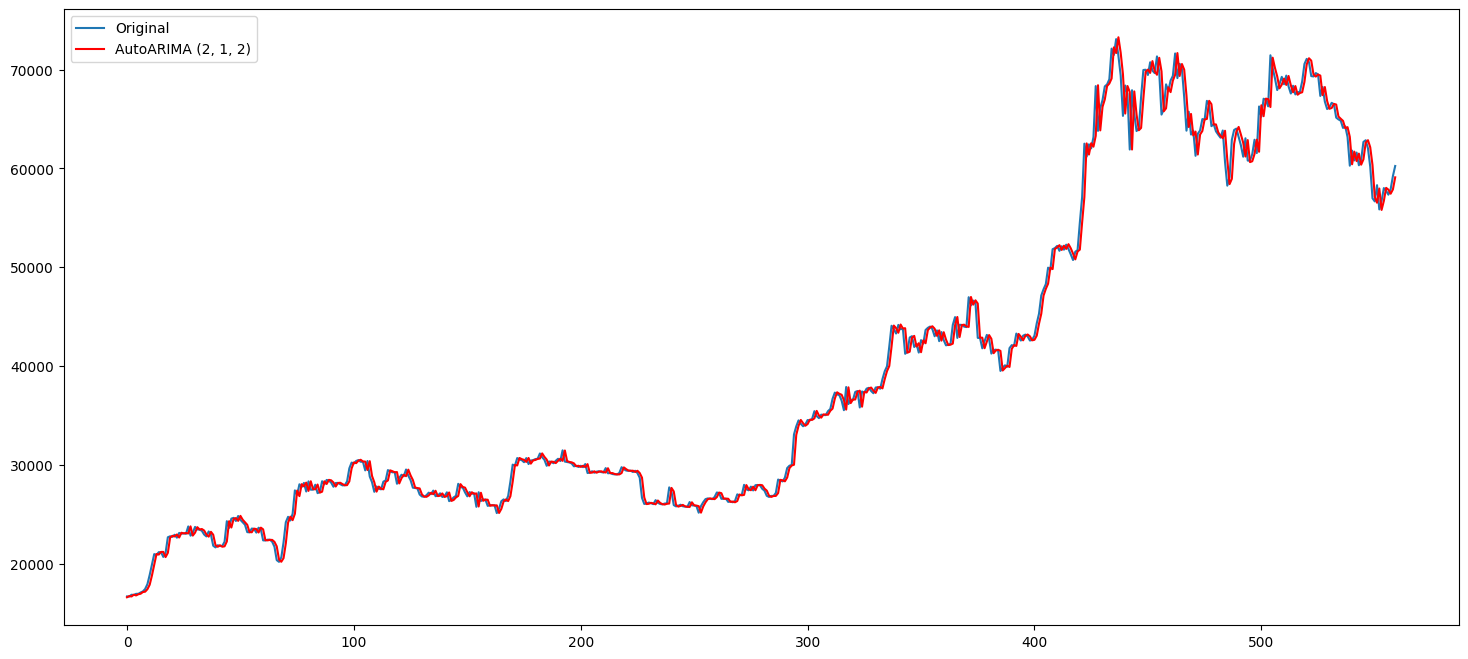

In [ ]:
plt.plot(df_test.Close.values, label='Original')
plt.plot(yhat.values, color='red', label='AutoARIMA {0}'.format(order))
plt.legend()

8. Seasonal Autoregressive Integrated Moving-Average (SARIMA)


Seasonal Autoregressive Integrated Moving Average, SARIMA or Seasonal ARIMA, is an extension of ARIMA that explicitly supports univariate time series data with a seasonal component.

It adds three new hyperparameters to specify the autoregression (AR), differencing (I) and moving average (MA) for the seasonal component of the series, as well as an additional parameter for the period of the seasonality.

SARIMA notation: SARIMA(p,d,q)(P,D,Q,m)

In [ ]:
# SARIMA example

# Walk throught the test data, training and predicting 1 day ahead for all the test data
index = len(df_training)
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    model = SARIMAX(temp_train.Close, order=(
        1, 0, 0), seasonal_order=(0, 0, 0, 3))
    model_fit = model.fit(disp=False)
    forecast_arimaA=model_fit.predict(start=len(df_training), end=len(df_training) + len(df_test) - 1, typ='levels')
    predictions = model_fit.predict(
        start=len(temp_train), end=len(temp_train), dynamic=False)
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['SARIMAX'] = evaluate(df_test.Close, yhat.values)
predictionsDict['SARIMAX'] = yhat.values

100%|██████████| 560/560 [02:19<00:00,  4.02it/s]


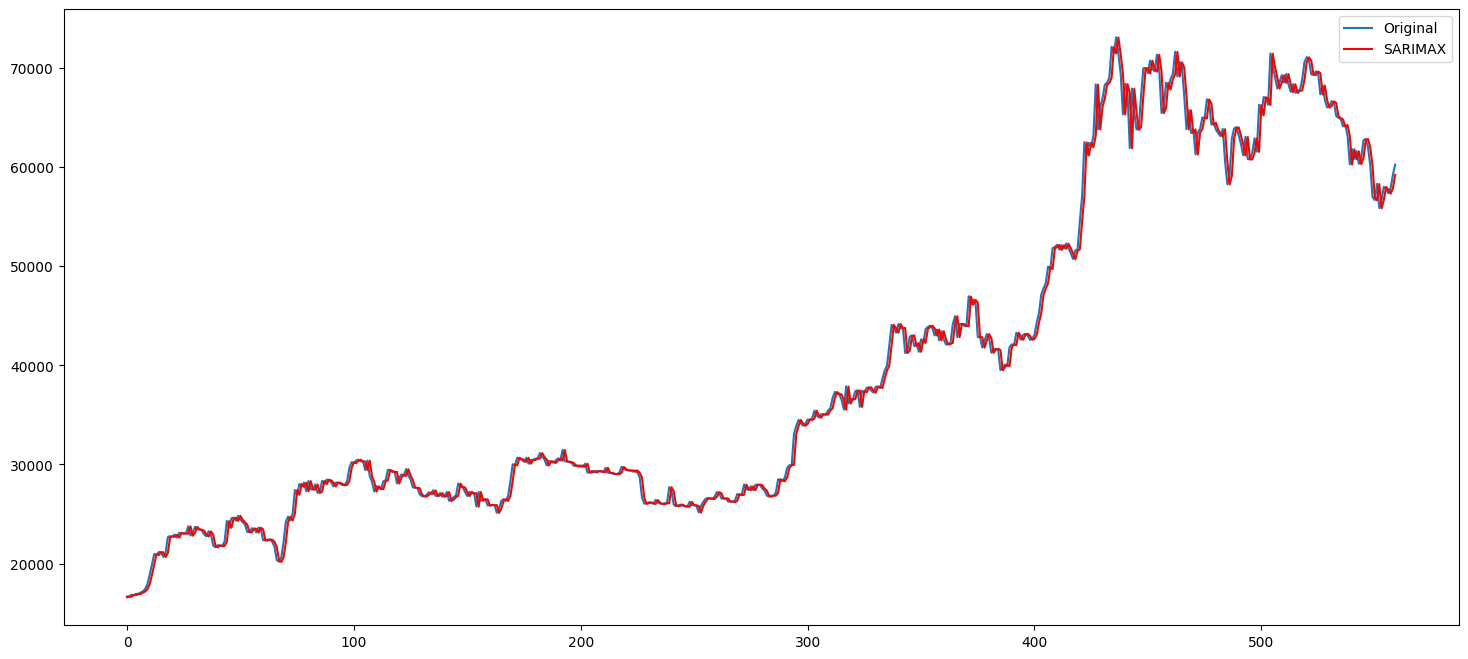

In [ ]:
plt.plot(df_test.Close.values, label='Original')
plt.plot(yhat.values, color='red', label='SARIMAX')
plt.legend()

9. Auto - SARIMA

In [ ]:
# building the model
autoModel = pm.auto_arima(df_training.Close, trace=True, error_action='ignore',
                          suppress_warnings=True, seasonal=True, m=6, stepwise=True)
autoModel.fit(df_training.Close)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[6] intercept   : AIC=inf, Time=13.88 sec
 ARIMA(0,1,0)(0,0,0)[6] intercept   : AIC=48675.540, Time=0.10 sec
 ARIMA(1,1,0)(1,0,0)[6] intercept   : AIC=48676.209, Time=0.56 sec
 ARIMA(0,1,1)(0,0,1)[6] intercept   : AIC=48676.034, Time=0.88 sec
 ARIMA(0,1,0)(0,0,0)[6]             : AIC=48673.678, Time=0.09 sec
 ARIMA(0,1,0)(1,0,0)[6] intercept   : AIC=48676.063, Time=0.81 sec
 ARIMA(0,1,0)(0,0,1)[6] intercept   : AIC=48675.848, Time=1.11 sec
 ARIMA(0,1,0)(1,0,1)[6] intercept   : AIC=48674.487, Time=1.77 sec
 ARIMA(1,1,0)(0,0,0)[6] intercept   : AIC=48675.572, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[6] intercept   : AIC=48675.592, Time=0.26 sec
 ARIMA(1,1,1)(0,0,0)[6] intercept   : AIC=48677.560, Time=0.34 sec

Best model:  ARIMA(0,1,0)(0,0,0)[6]          
Total fit time: 20.016 seconds


ARIMA(order=(0, 1, 0), scoring_args={}, seasonal_order=(0, 0, 0, 6),
      suppress_warnings=True, with_intercept=False)

In [ ]:
order = autoModel.order
seasonalOrder = autoModel.seasonal_order
yhat = list()
for t in tqdm(range(len(df_test.Close))):
    temp_train = doc1[:len(df_training)+t]
    model = SARIMAX(temp_train.Close, order=order,
                    seasonal_order=seasonalOrder)
    model_fit = model.fit(disp=False)
    forecast_sarimaA=model_fit.predict(start=len(df_training), end=len(df_training) + len(df_test) - 1, typ='levels')
    predictions = model_fit.predict(
        start=len(temp_train), end=len(temp_train), dynamic=False)
    yhat = yhat + [predictions]

yhat = pd.concat(yhat)
resultsDict['AutoSARIMAX {0},{1}'.format(order, seasonalOrder)] = evaluate(
    df_test.Close, yhat.values)
predictionsDict['AutoSARIMAX {0},{1}'.format(
    order, seasonalOrder)] = yhat.values
k=yhat.values

100%|██████████| 560/560 [00:34<00:00, 16.35it/s]


In [ ]:
forecast_arima = results_arima.predict(start=len(train), end=len(train) + len(test) - 1, typ='levels')

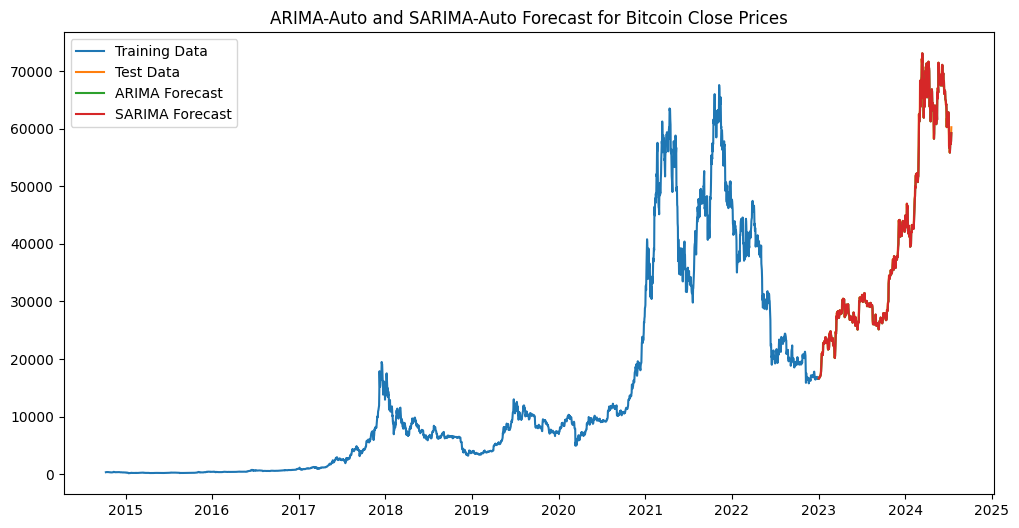

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_training['Close'], label='Training Data')
plt.plot(df_test['Close'], label='Test Data')
plt.plot(forecast_arimaA, label='ARIMA Forecast')
plt.plot(forecast_sarimaA, label='SARIMA Forecast')

plt.title('ARIMA-Auto and SARIMA-Auto Forecast for Bitcoin Close Prices')
plt.legend()
plt.show()

10. Forecast of future values using Auto-SARIMA model:

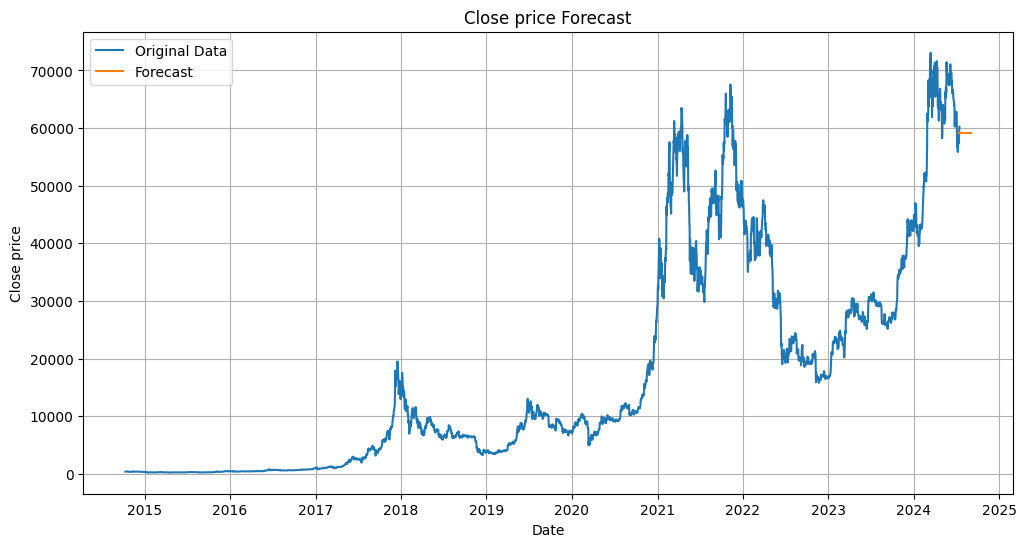

In [ ]:

# Forecast future values for SARIMA model
forecast_steps = 50 # Adjust this as needed
forecast = model_fit.get_forecast(steps=forecast_steps)

date_range = pd.date_range(start=doc1.index[-1], periods=forecast_steps + 1, freq='H')

# Get forecasted values and confidence intervals
forecast_values = forecast.predicted_mean

# Create a forecast DataFrame
forecast_df = pd.DataFrame({'Forecast': forecast_values}, index=forecast_values.index)

plt.figure(figsize=(12, 6))

plt.plot(doc1['Close'], label='Original Data')
plt.plot(forecast_df['Forecast'], label='Forecast')

plt.title('Close price Forecast')
plt.xlabel('Date')
plt.ylabel('Close price')
plt.legend()
plt.grid(True)
plt.show()

The forecast line begins where the original data ends, extending into the future for a specified number of steps (50 in this case). It indicates the model's projected path for Bitcoin's closing price. The visual comparison allows us to see how the model's forecast looks in relation to the historical trend.

Multivariate time series forecasting

In [12]:
# ADD time features to our model
def create_time_features(df, target=None):
    """
    Creates time series features from date index
    """
    df['date'] = df.index
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['sin_day'] = np.sin(df['dayofyear'])
    df['cos_day'] = np.cos(df['dayofyear'])
    df['dayofmonth'] = df['date'].dt.day
    # Fix: Replace .dt.weekofyear with .dt.isocalendar().week
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    X = df.drop(['date'], axis=1)
    if target:
        y = df[target]
        X = X.drop([target], axis=1)
        return X, y

    return X

In [13]:
X_train_df, y_train = create_time_features(
    df_training, target='Close')
X_test_df, y_test = create_time_features(df_test, target='Close')
scaler = StandardScaler()
scaler.fit(X_train_df)  # No cheating, never scale on the training+test!
X_train = scaler.transform(X_train_df)
X_test = scaler.transform(X_test_df)

X_train_df = pd.DataFrame(X_train, columns=X_train_df.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test_df.columns)

**9. Linear models**

1. Bayesian regression

In [ ]:
reg = linear_model.BayesianRidge()
reg.fit(X_train, y_train)
yhat = reg.predict(X_test)
resultsDict['BayesianRidge'] = evaluate(df_test.Close, yhat)
predictionsDict['BayesianRidge'] = yhat

2. Lasso

In [ ]:
reg = linear_model.Lasso(alpha=0.1)
reg.fit(X_train, y_train)
yhat = reg.predict(X_test)
resultsDict['Lasso'] = evaluate(df_test.Close, yhat)
predictionsDict['Lasso'] = yhat

**10. Tree Models**

1. Randomforest

In [ ]:
reg = RandomForestRegressor(max_depth=2, random_state=0)
reg.fit(X_train, y_train)
yhat = reg.predict(X_test)
resultsDict['Randomforest'] = evaluate(df_test.Close, yhat)
predictionsDict['Randomforest'] = yhat

2. XGBoost

In [ ]:
reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000)
reg.fit(X_train, y_train,
        verbose=False)  # Change verbose to True if you want to see it train
yhat = reg.predict(X_test)
resultsDict['XGBoost'] = evaluate(df_test.Close, yhat)
predictionsDict['XGBoost'] = yhat

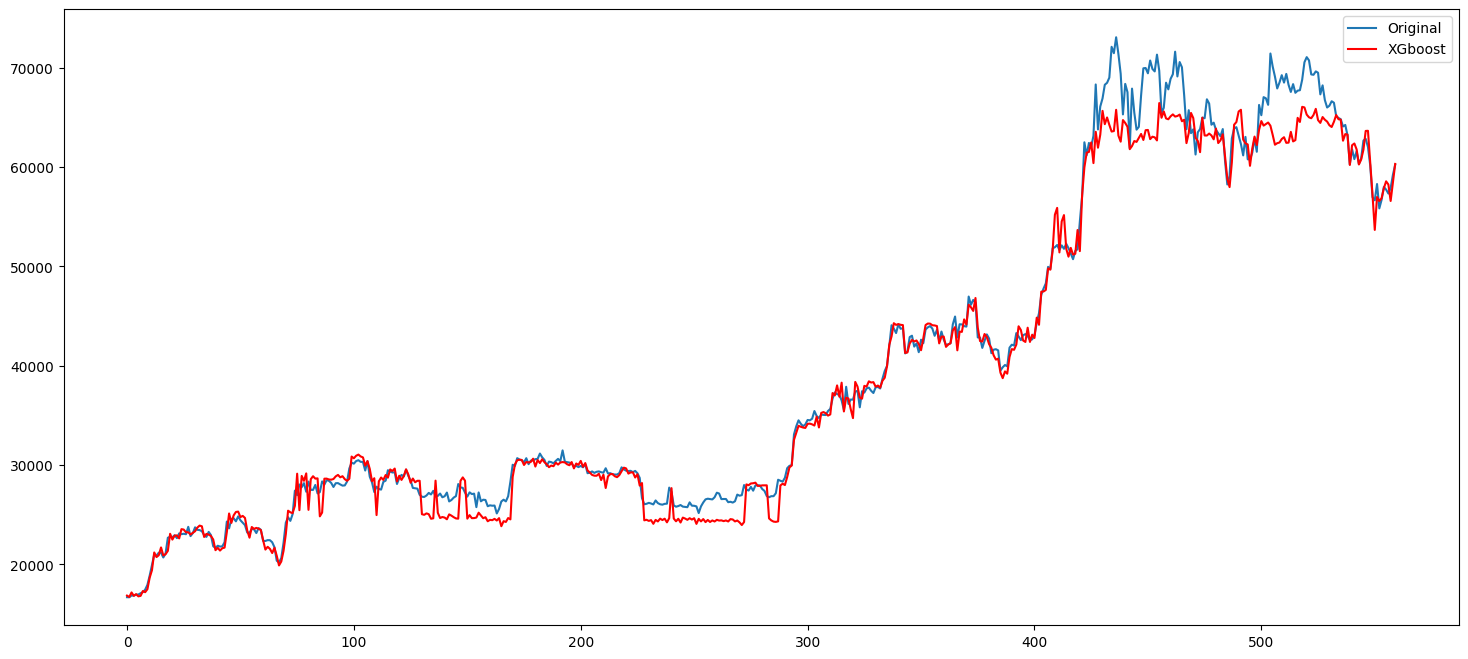

In [ ]:
plt.plot(df_test.Close.values, label='Original')
plt.plot(yhat, color='red', label='XGboost')
plt.legend()

3. Lightgbm

In [15]:
import lightgbm as lgb
lightGBM = lgb.LGBMRegressor()
lightGBM.fit(X_train, y_train)
yhat = lightGBM.predict(X_test)
resultsDict['Lightgbm'] = evaluate(df_test.Close, yhat)
predictionsDict['Lightgbm'] = yhat

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000960 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 3006, number of used features: 14
[LightGBM] [Info] Start training from score 12958.898533


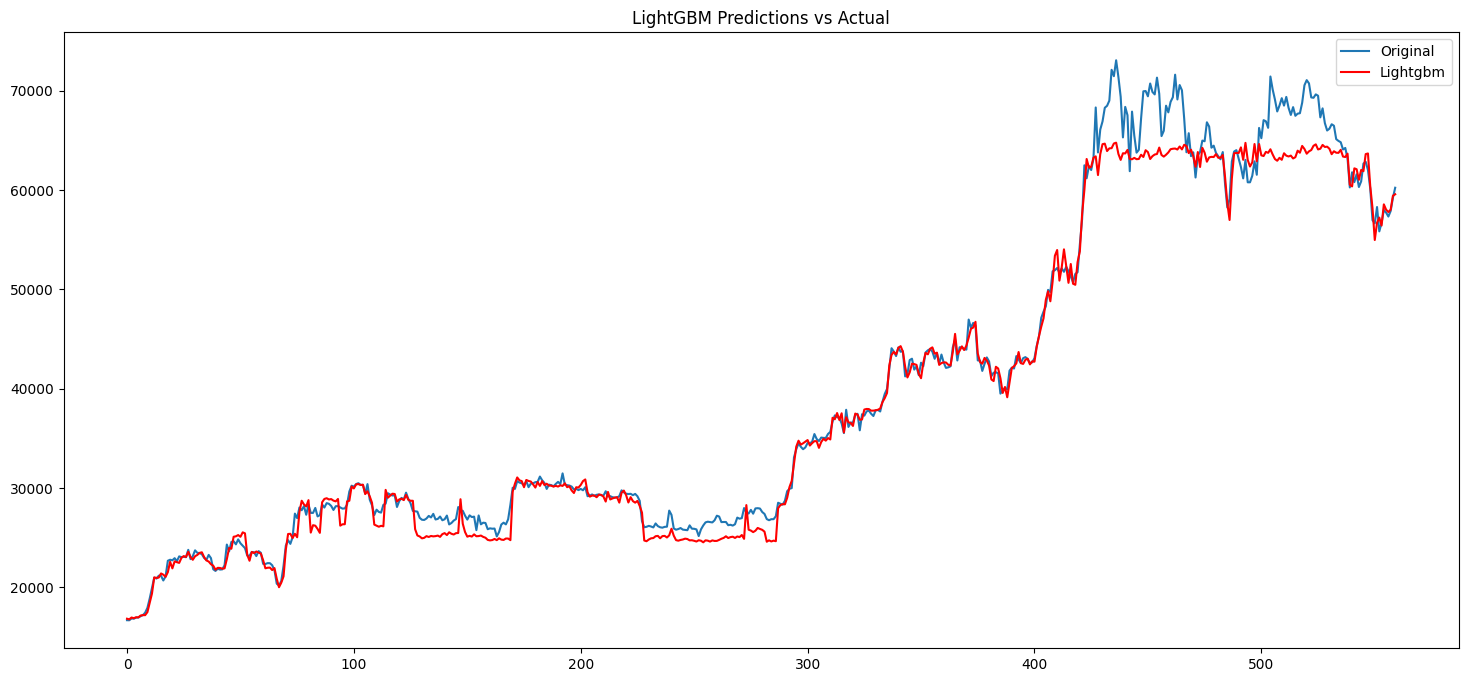

In [ ]:
plt.plot(df_test.Close.values, label='Original')
plt.plot(predictionsDict['Lightgbm'], color='red', label='Lightgbm')
plt.legend()
plt.title('LightGBM Predictions vs Actual')
plt.show()

**11. Support vector machines**


1. Kernels

In [ ]:
reg = svm.SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
reg.fit(X_train, y_train)
yhat = reg.predict(X_test)
resultsDict['SVM RBF'] = evaluate(df_test.Close, yhat)
predictionsDict['SVM RBF'] = yhat

2. Nearest neighbors

In [ ]:
reg = KNeighborsRegressor(n_neighbors=2)
reg.fit(X_train, y_train)
yhat = reg.predict(X_test)
resultsDict['Kneighbors'] = evaluate(df_test.Close, yhat)
predictionsDict['Kneighbors'] = yhat

12. Hyperparameter optimization

1. Grid search - SVM

In [ ]:
reg = GridSearchCV(svm.SVR(kernel='rbf', gamma=0.1),
                   param_grid={"C": [1e0, 1e1, 1e2, 1e3],
                               "gamma": np.logspace(-2, 2, 5)})
reg.fit(X_train, y_train)
yhat = reg.predict(X_test)
resultsDict['SVM RBF GRID SEARCH'] = evaluate(df_test.Close, yhat)
predictionsDict['SVM RBF GRID SEARCH'] = yhat

In [ ]:
increase = 1 - (resultsDict['SVM RBF GRID SEARCH']
                /resultsDict['SVM RBF'])
print(
    f"Grid search Tunned SVM is {increase*100:.2f}% better than the SVM with default parameters")

Grid search Tunned SVM is 98.03% better than the SVM with default parameters


2. Bayesian processes - Xgboost

In [ ]:
def rms(y_actual, y_predicted):
    return sqrt(mean_squared_error(y_actual, y_predicted))


my_scorer = make_scorer(rms, greater_is_better=False)
pbounds = {
    'n_estimators': (100, 10000),
    'max_depth': (3, 15),
    'min_samples_leaf': (1, 4),
    'min_samples_split': (2, 10),
}


def rf_hyper_param(n_estimators,
                   max_depth,
                   min_samples_leaf,
                   min_samples_split):

    max_depth = int(max_depth)
    n_estimators = int(n_estimators)

    clf = RandomForestRegressor(n_estimators=n_estimators,
                                max_depth=int(max_depth),
                                min_samples_leaf=int(min_samples_leaf),
                                min_samples_split=int(min_samples_split),
                                n_jobs=1)

    return -np.mean(cross_val_score(clf, X_train, y_train, cv=3))


optimizer = BayesianOptimization(
    f=rf_hyper_param,
    pbounds=pbounds,
    random_state=1,
)

In [ ]:
params = optimizer.max['params']

# Converting the max_depth and n_estimator values from float to int
params['max_depth'] = int(params['max_depth'])
params['n_estimators'] = int(params['n_estimators'])
params['min_samples_leaf'] = int(params['min_samples_leaf'])
params['min_samples_split'] = int(params['min_samples_split'])

# Initialize an XGBRegressor with the tuned parameters and fit the training data
tunned_rf = RandomForestRegressor(**params)
# Change verbose to True if you want to see it train
tunned_rf.fit(X_train, y_train)

yhat = tunned_rf.predict(X_test)
resultsDict['Randomforest tunned'] = evaluate(y_test, yhat)

In [ ]:
increase = 1 - (resultsDict['Randomforest tunned']
                /resultsDict['Randomforest'])
print(
    f"Bayesian optimized Randomforest is {increase*100:.2f}% better than the Randomforest with default parameters")

Bayesian optimized Randomforest is 71.02% better than the Randomforest with default parameters


**13. Deep learning**

Tensorlfow LSTM

In [ ]:
# For our dl model we will create windows of data that will be feeded into the datasets, for each timestemp T we will append the data from T-7 to T to the Xdata with target Y(t)
BATCH_SIZE = 64
BUFFER_SIZE = 100
WINDOW_LENGTH = 24


def window_data(X, Y, window=7):
    '''
    The dataset length will be reduced to guarante all samples have the window, so new length will be len(dataset)-window
    '''
    x = []
    y = []
    for i in range(window-1, len(X)):
        x.append(X[i-window+1:i+1])
        y.append(Y[i])
    return np.array(x), np.array(y)


# Since we are doing sliding, we need to join the datasets again of train and test
X_w = np.concatenate((X_train, X_test))
y_w = np.concatenate((y_train, y_test))

X_w, y_w = window_data(X_w, y_w, window=WINDOW_LENGTH)
X_train_w = X_w[:-len(X_test)]
y_train_w = y_w[:-len(X_test)]
X_test_w = X_w[-len(X_test):]
y_test_w = y_w[-len(X_test):]

# Check we will have same test set as in the previous models, make sure we didnt screw up on the windowing
print(f"Test set equal: {np.array_equal(y_test_w,y_test)}")

train_data = tf.data.Dataset.from_tensor_slices((X_train_w, y_train_w))
train_data = train_data.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data = tf.data.Dataset.from_tensor_slices((X_test_w, y_test_w))
val_data = val_data.batch(BATCH_SIZE).repeat()

dropout = 0.0
simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(
        128, input_shape=X_train_w.shape[-2:], dropout=dropout),
    tf.keras.layers.Dense(128),
    tf.keras.layers.Dense(128),
    tf.keras.layers.Dense(1)
])

simple_lstm_model.compile(optimizer='rmsprop', loss='mae')

dropout = 0.0
simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(
        128, input_shape=X_train_w.shape[-2:], dropout=dropout),
    tf.keras.layers.Dense(128),
    tf.keras.layers.Dense(128),
    tf.keras.layers.Dense(1)
])

simple_lstm_model.compile(optimizer='rmsprop', loss='mae')
EVALUATION_INTERVAL = 200
EPOCHS = 5

model_history = simple_lstm_model.fit(train_data, epochs=EPOCHS,
                                      steps_per_epoch=EVALUATION_INTERVAL,
                                      validation_data=val_data, validation_steps=50)  # ,callbacks=[tensorboard_callback]) #Uncomment this line for tensorboard support
yhat = simple_lstm_model.predict(X_test_w).reshape(1, -1)[0]
resultsDict['Tensorflow simple LSTM'] = evaluate(y_test, yhat)
predictionsDict['Tensorflow simple LSTM'] = yhat


Test set equal: True


In [ ]:
models = ['Tensorflow simple LSTM',
          'Lightgbm',
          'XGBoost']
resis = pd.DataFrame(data={k: df_test.Close.values -
                     v for k, v in predictionsDict.items()})[models]
corr = resis.corr()
print("Residuals correlation")
corr.style.background_gradient(cmap='coolwarm')

Residuals correlation


,Tensorflow simple LSTM,Lightgbm,XGBoost
Tensorflow simple LSTM,1.000000,0.642922,0.597753
Lightgbm,0.642922,1.000000,0.877451
XGBoost,0.597753,0.877451,1.000000


# 14. Ensembling

Ensembling refers to combine multiple models to achieve a better performance, most of the time this only makes sense when models have similar performance but predict values differently so we try to get the best of each model.

The most reasonable combinations to try would be

XGboost + Tensorflow
XGBoost + Lightgbm
Lightgbm + Tensorflow
XGBoost + Lightgbm + Tensorflow

In [ ]:
predictionsDict['EnsembleXG+LIGHT'] = (
    predictionsDict['XGBoost'] + predictionsDict['Lightgbm'])/2
resultsDict['EnsembleXG+LIGHT'] = evaluate(
    df_test.Close.values, predictionsDict['EnsembleXG+LIGHT'])

predictionsDict['EnsembleXG+LIGHT+TF'] = (predictionsDict['XGBoost'] +
                                          predictionsDict['Lightgbm'] + predictionsDict['Tensorflow simple LSTM'])/3
resultsDict['EnsembleXG+LIGHT+TF'] = evaluate(
    df_test.Close.values, predictionsDict['EnsembleXG+LIGHT+TF'])

predictionsDict['EnsembleLIGHT+TF'] = (
    predictionsDict['Lightgbm'] + predictionsDict['Tensorflow simple LSTM'])/2
resultsDict['EnsembleLIGHT+TF'] = evaluate(
    df_test.Close.values, predictionsDict['EnsembleLIGHT+TF'])

predictionsDict['EnsembleXG+TF'] = (predictionsDict['XGBoost'] +
                                    predictionsDict['Tensorflow simple LSTM'])/2
resultsDict['EnsembleXG+TF'] = evaluate(
    df_test.Close.values, predictionsDict['EnsembleXG+TF'])

**Model performance Comparision**

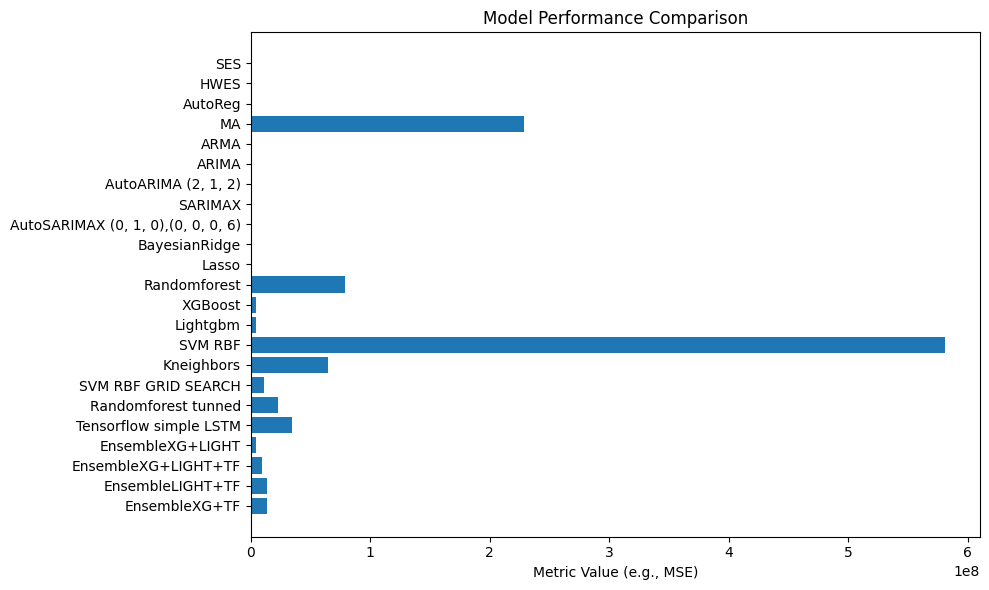

In [ ]:




bar_metrics(resultsDict)

**Feature importance**

Some models allow for for native feature importance algorithms but I personally like the library SHAP that provides a game theory approach to measure how each feature affects our forecast.

Here is an example on how to use SHAP for our Lightgbm model

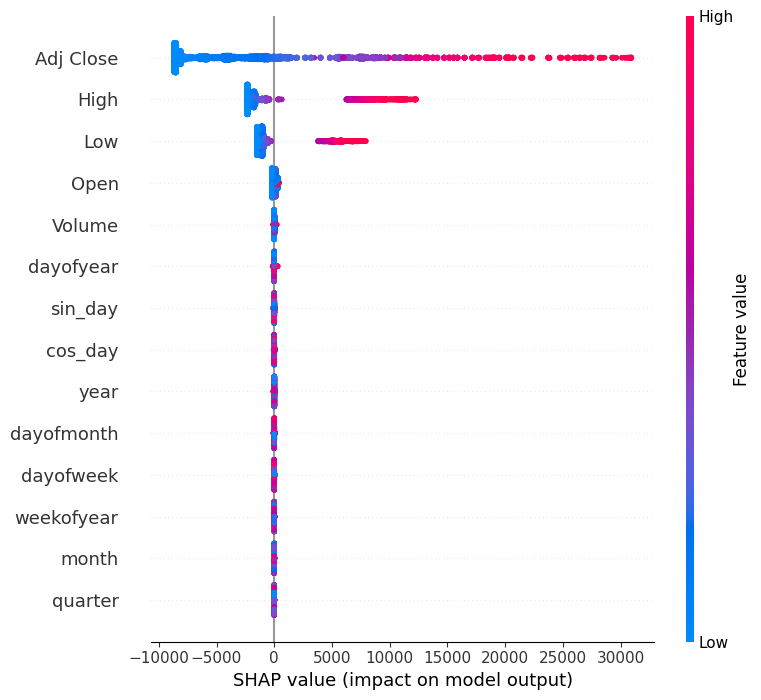

In [16]:
explainer = shap.TreeExplainer(lightGBM)
shap_values = explainer.shap_values(X_train_df)
shap.summary_plot(shap_values, X_train_df)

The plot will display features ordered by their overall importance, and for each feature, colored dots will indicate whether a high or low feature value pushes the prediction higher or lower.


**15. Conclusion:**

Essentially, by looking at these bar charts, you can quickly compare which models produced the smallest errors (both average and in terms of larger deviations) and thus performed better in forecasting the Bitcoin close prices. Generally, models with shorter bars (lower RMSE and MAE values) are considered more accurate.

The models which are preferred in forecasting Bitcoin Close prices are XGBoost, Lightgbm and the Ensembling methods like XG+Light and XG+Light+TF.
